# AI-агент для суммаризации и извлечения метрик из документов

В этом ноутбуке мы **пошагово** строим AI-агента на LangGraph, который умеет:
1. **Суммаризировать** PDF-документ — создавать краткое информативное резюме
2. **Извлекать метрики** — находить количественные, временные и качественные показатели

На каждом шаге мы добавляем новую способность или улучшаем архитектуру, демонстрируя ключевые паттерны построения агентов:

| Шаг | Что добавляем |
|-----|---------------|
| 1 | Базовая суммаризация — минимальный агент |
| 2 | Улучшенный промпт — промпт-инжиниринг |
| 3 | Извлечение метрик — второй навык агента |
| 4 | Улучшенный промпт для метрик |
| 5 | Map-Reduce + параллелизация |
| 6 | Парсинг изображений |
| 7 | Финальная архитектура — полный документ с изображениями |

## Документ для анализа
`input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf` — отчёт Gartner о 10 стратегических технологических трендах 2026 года (~40 страниц, содержит диаграммы, таблицы и прогнозы).

# Эталоны для сравнения

Перед началом работы определим эталонные результаты, с которыми будем сверяться на каждом шаге.

In [1]:
# Эталон суммаризации (NotebookLM) — для визуального сравнения
ETALON = (
    "Этот отчет компании Gartner представляет десять ключевых технологических стратегий, "
    "которые станут определяющими для бизнеса к 2026 году. Эксперты распределили актуальные "
    "направления по трём фундаментальным категориям: создание надёжной цифровой базы, интеграция "
    "интеллектуальных систем и укрепление информационной безопасности. Особое внимание уделяется "
    "переходу к узкоспециализированным языковым моделям, автономным системам ИИ и защищённым "
    "вычислительным средам. Документ содержит практические планы действий для руководителей, "
    "стремящихся адаптировать свои организации к условиям гиперподключённого мира. Авторы подчёркивают, "
    "что успех будет зависеть от способности компаний оперативно внедрять инновации, сохраняя при этом "
    "высокий уровень доверия и прозрачности в использовании данных. Таким образом, руководство служит "
    "дорожной картой для достижения долгосрочного конкурентного преимущества в эпоху тотальной "
    "цифровой трансформации."
)
print("Эталон суммаризации (NotebookLM):")
print(ETALON)

Эталон суммаризации (NotebookLM):
Этот отчет компании Gartner представляет десять ключевых технологических стратегий, которые станут определяющими для бизнеса к 2026 году. Эксперты распределили актуальные направления по трём фундаментальным категориям: создание надёжной цифровой базы, интеграция интеллектуальных систем и укрепление информационной безопасности. Особое внимание уделяется переходу к узкоспециализированным языковым моделям, автономным системам ИИ и защищённым вычислительным средам. Документ содержит практические планы действий для руководителей, стремящихся адаптировать свои организации к условиям гиперподключённого мира. Авторы подчёркивают, что успех будет зависеть от способности компаний оперативно внедрять инновации, сохраняя при этом высокий уровень доверия и прозрачности в использовании данных. Таким образом, руководство служит дорожной картой для достижения долгосрочного конкурентного преимущества в эпоху тотальной цифровой трансформации.


In [2]:
# Эталон метрик (NotebookLM) — промпт и результат для сравнения
prompt_notebook_lm = """Найди метрики (временные, количественные, качественные) в этом документе. Найденные метрики сгруппируй по призканам. Примеры признаков:
    связанные с кибер атаками
    связанные с защитой кибер периметра
    связанные с сетью
    связанные с системами
    связанные с бизнес процессами.
    Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. Если поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки
"""

result_notebook_ml = """На основе предоставленного документа Gartner, ниже приведен перечень метрик (количественных, временных и качественных), сгруппированных по предложенным и дополнительным признакам.
1. Метрики, связанные с киберугрозами и атаками
В этой группе представлены количественные показатели масштаба угроз, с которыми столкнутся организации к 2030 году.
    Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году.
    Природа угроз ИИ: 80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности, а не с внешними атаками.
2. Метрики, связанные с защитой киберпериметра и безопасностью
Эти метрики отражают переход к новым методам защиты данных и инфраструктуры.
    Инвестиции в упреждающую защиту: К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей (preemptive) кибербезопасности.
    Защита данных в процессе обработки: К 2029 году 75% процессов обработки данных в недоверенной инфраструктуре будут защищены с помощью конфиденциальных вычислений.
    Внедрение платформ безопасности ИИ (AISP): Более 50% предприятий внедрят специализированные платформы безопасности ИИ к 2028 году.
    Рыночная релевантность: К 2029 году технологические продукты, не обладающие функциями упреждающей безопасности, потеряют актуальность на рынке.
3. Метрики, связанные с системами и инфраструктурой
Показатели трансформации вычислительных мощностей и способов размещения рабочих нагрузок.
    Гибридные вычисления: 40% предприятий перейдут на гибридные вычислительные архитектуры к 2028 году (значительный рост по сравнению с 8% в 2025 году).
    Рынок суперкомпьютеров ИИ: К 2028 году более 20 поставщиков предложат унифицированные платформы для разработчиков, использующие среды суперкомпьютерных вычислений.
    Геопатриация (локализация): К 2030 году 75% предприятий перенесут свои рабочие нагрузки из глобальных публичных облаков в суверенные или локальные среды («геопатриация»).
    Локальный ИИ: К 2028 году 30% рабочих нагрузок генеративного ИИ (GenAI) будут использовать отраслевые модели (DSLM), работающие локально или непосредственно на устройствах.
4. Метрики, связанные с разработкой ПО и кадрами
Метрики, описывающие качественные и количественные изменения в структуре команд и методах создания приложений.
    Эволюция команд: К 2030 году 80% организаций заменят крупные команды инженеров ПО на маленькие группы, усиленные ИИ («tiny teams»).
    Доля AI-native приложений: К 2030 году 40% портфеля корпоративных приложений будут составлять кастомные решения, созданные на AI-native платформах (в 2025 году этот показатель составляет всего 2%).
    Интерес к мультиагентным системам (MAS): Зафиксирован взрывной рост интереса — количество запросов по MAS увеличилось на 1445% в период с 1 кв. 2024 по 2 кв. 2025 года.
    Эффективность команд: Пример качественного изменения — возможность для 5 команд из 2 человек поставлять 5 приложений одновременно благодаря инструментам генеративного ИИ.
5. Метрики, связанные с бизнес-процессами и отраслевой спецификой
Показатели автоматизации физических и операционных процессов.
    Автоматизация складов: К 2028 году 80% складов будут использовать робототехнику или средства автоматизации.
    Отраслевая специализация ИИ: К 2028 году 50% всех корпоративных моделей GenAI будут узкоспециализированными (domain-specific), а не общими.
    Специализация ИИ-агентов: К 2027 году 70% мультиагентных систем будут состоять из узкоспециализированных агентов для повышения точности.
    Совместимость решений: К 2028 году 60% мультиагентных систем будут поддерживать работу с решениями от разных вендоров (multivendor interoperability)"""

print("Эталон метрик (NotebookLM):")
print(result_notebook_ml)

Эталон метрик (NotebookLM):
На основе предоставленного документа Gartner, ниже приведен перечень метрик (количественных, временных и качественных), сгруппированных по предложенным и дополнительным признакам.
1. Метрики, связанные с киберугрозами и атаками
В этой группе представлены количественные показатели масштаба угроз, с которыми столкнутся организации к 2030 году.
    Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году.
    Природа угроз ИИ: 80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности, а не с внешними атаками.
2. Метрики, связанные с защитой киберпериметра и безопасностью
Эти метрики отражают переход к новым методам защиты данных и инфраструктуры.
    Инвестиции в упреждающую защиту: К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей (preemptive) кибербезопасности.
    Защита данных в процессе обработки: К 2029 году 75% проце

# Импорты и настройка

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [4]:
%load_ext autoreload
%autoreload 2

from blanks.prompts import structured_sys
from glob import glob
import operator
from typing import TypedDict, List, Dict, Any, Callable
from typing_extensions import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from langgraph.types import Send
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import MessagesState
from typing_extensions import NotRequired
from langgraph.types import Command
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import AgentMiddleware, wrap_model_call, ModelRequest, ModelResponse
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langchain.agents import create_agent, AgentState
from langchain.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_gigachat.chat_models import GigaChat

from rich.console import Console
from rich.panel import Panel
from rich.text import Text




from docling_core.types.doc import DoclingDocument

from dotenv import load_dotenv
from IPython.display import Image
from rich import print
import pandas as pd

from src.tools import parse_pdf_docling, make_parse_pdf_gigachat_postprocess
from src.utils import show_prompt, format_messages


console = Console()

In [5]:
load_dotenv()
key = os.environ.get('GIGACHAT_API_KEY')

llm = GigaChat(
    credentials=key,
    model='GigaChat-2-Max',
    scope='GIGACHAT_API_CORP',
    temperature=0.87,
    verify_ssl_certs=False,
    profanity_check=False,
    max_tokens=25000,
    timeout=300,
)

# для парсинга метрик выставляем температуру в 0
parse_llm = GigaChat(
    credentials=key,
    model='GigaChat-2-Max',
    scope='GIGACHAT_API_CORP',
    temperature=0,
    verify_ssl_certs=False,
    profanity_check=False,
    max_tokens=25000,
    timeout=300,
)

# Промпты

Собираем все промпты в одном месте. По ходу ноутбука будем ссылаться на них по имени.

In [6]:
# === Промпты для суммаризации ===

# Шаг 1: минимальный промпт — даём модели максимум свободы
STEP1_SUMMARY_PROMPT = "Кратко суммаризируй следующий документ на русском языке. Объём: 5-10 предложений."

# Шаг 2: структурированный промпт с явными требованиями к содержанию
STEP2_SUMMARY_PROMPT = """Ты эксперт по технологическим трендам. Создай краткое, но информативное резюме отчёта на русском языке (5–7 предложений).

Резюме обязательно должно отражать:
1. Общую тему и цель отчётад, укажи компанию, год.
2. Опиши главные мысли и идеи.
3. Перечисли упоминаемые тренды, технологии, концепции и другие значимые артефакты из отчёта, если они есть (например: специализированные языковые модели, мультиагентные системы, конфиденциальные вычисления, геопатриация данных).
4. Упоминание практических планов, действий для руководителей.
5. Подытожь основной посыл

Пиши связным текстом без маркированных списков. Объём: 5–10 предложений."""

# === Промпты для извлечения метрик ===

# Шаг 3: базовый промпт метрик (тот же, что использовался в NotebookLM для честного сравнения)
# prompt_notebook_lm — определён выше

# Шаг 4+: улучшенный промпт метрик с ролью аналитика и строгим форматом
new_prompt = '''Ты специалист по кибербезопасности, который занимается профессиональной публицистикой и глубоким анализом аналитических отчетов \
в сфере кибербезопасности.
Проанализируй документ ниже и найди метрики (временные, количественные, качественные).
Метрики могут быть либо явно указаны в тексте документа, либо сформулированы тобой исходя описания возможных изменений \
(рост, снижение, изменение интенсивности чего-либо и т.д.). 
Метрики ОБЯЗАТЕЛЬНО должны выражаться какими-то числовыми значениями. \
Если есть какое-то описание метрики, но нет цифрового выражения, то эту метрику описывать не нужно. 
Для каждой метрики необходимо указать краткое емкое название и описание, что именно метрика показывает (исходное в тексте либо сформулированное тобой) \
в описании обязательно должно быть цифровое выражение этой метрики. 
Обрати внимание, что метрики могут быть временные, количественные, качественные. \
Необходимо найти и описать ВСЕ метрики, упомянутые в документе. В случае отсутствия метрик укажи "Отчет не содержит метрик". \
Если метрики найдены, сгруппируй по призканам. Примеры признаков:
    связанные с кибер атаками
    связанные с защитой кибер периметра
    связанные с сетью
    связанные с системами
    связанные с бизнес процессами.
Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. \
Если поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки.
Формат вывода: нумерованный список групп метрик. В каждой групп ненумерованный список метрик, входящих в эту группу.
Формат вывода метрик: "Название метрики: Описание метрики вместе с числовыми показателями".
Пример: 
"1. Метрики, связанные с киберугрозами и атаками
    - Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 100 ежегодно к 2028 году.
    - Природа угроз ИИ: 90% несанкционированных транзакций ИИ будут связаны с нарушениями политик безопасности, а не с внешними атаками."
'''

# === Промпт для анализа изображений (шаги 6-7) ===

IMAGE_ANALYSIS_PROMPT = '''Подробно опиши данные на изображении. 
Если есть текст, числа, графики, диаграммы или схемы — извлеки их максимально дословно.
Отвечай на русском языке.
'''

In [7]:
# Фабрика для создания узлов извлечения метрик с фиксированным промптом
def make_extract_metrics(prompt: str):
    def extract_metrics(state) -> Dict[str, Any]:
        message = [
            SystemMessage(content=prompt),
            HumanMessage(content=f"Документ:\n{state['doc_markdown']}")
        ]
        result = llm.invoke(message)
        return {"report_md": result.content}
    return extract_metrics

---

# Шаг 1. Базовый агент: один вызов LLM на весь документ

Начинаем с простейшего агента: загружаем PDF, конвертируем в текст, передаём весь текст в LLM с минимальным промптом. Модель сама решает, что считать важным.

**Обратите внимание:**
- Базовый паттерн LangGraph: определяем **состояние** (`GraphState`), создаём **узлы** (функции, трансформирующие состояние), соединяем **рёбрами**
- Промпт минимальный — это наш baseline для оценки последующих улучшений

**Граф:**
```
parse_pdf_docling → summarize → END
```

In [63]:
# Схема состояния для шагов 1-2: минимальный набор полей
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str

In [64]:
show_prompt(STEP1_SUMMARY_PROMPT, title="Промпт шага 1")


def summarize_step1(state: GraphState) -> Dict[str, Any]:
    messages = [
        SystemMessage(content=STEP1_SUMMARY_PROMPT),
        HumanMessage(content=state["doc_markdown"]),
    ]
    result = llm.invoke(messages)
    return {"summary": result.content}

╭───────────────────────────────────────────────── Промпт шага 1 ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Кратко суммаризируй следующий документ на русском языке. Объём: 5-10 предложений.                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

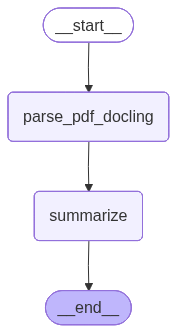

In [65]:
# Строим граф: два узла, линейная цепочка
graph = StateGraph(GraphState)
graph.add_node("parse_pdf_docling", parse_pdf_docling)
graph.add_node("summarize", summarize_step1)

graph.add_edge(START, "parse_pdf_docling")
graph.add_edge("parse_pdf_docling", "summarize")
graph.add_edge("summarize", END)

app_step1 = graph.compile()
Image(app_step1.get_graph().draw_mermaid_png())

In [12]:
state = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result1 = app_step1.invoke(state)

In [13]:
print("[bold]--- Суммаризация (Шаг 1) ---[/bold]")
print(result1["summary"])

--- Суммаризация (Шаг 1) ---

Документ представляет собой отчет о стратегических технологических трендах на 2026 год от компании Gartner. В нем 
выделены три ключевые темы, определяющие будущее развитие технологий и их влияние на бизнес:

1. **Архитектор**: создание безопасных цифровых основ с использованием платформ разработки на основе искусственного
интеллекта (ИИ), суперкомпьютеров для ИИ и конфиденциального вычисления.
   
2. **Синтезатор**: интеграция специализированных моделей и систем искусственного интеллекта для создания адаптивных
экосистем, включая мультиагентные системы, языковые модели для конкретных областей и физический искусственный 
интеллект.

3. **Авангард**: повышение доверия через упреждающую кибербезопасность, цифровую аутентичность данных, платформы 
безопасности для ИИ и геопатризацию — перенос критических рабочих нагрузок в местные или суверенные облачные среды.

Отчет содержит подробные рекомендации по внедрению этих тенденций и созданию устойчивых конкурентных преимуществ за
счет цифровой трансформации. Он также предлагает шаблоны стратегического планирования и инструменты оценки решений 
для ИТ-лидеров.

Итог: найдено 0 метрик из 18

---

# Шаг 2. Структурированный промпт: задаём требования к содержанию

Архитектура графа не меняется — только системный промпт. Это позволяет честно оценить вклад именно **промпт-инжиниринга**.

**Обратите внимание:**
- Тот же граф, то же состояние — другие инструкции
- Явные структурные требования (тема, технологии, планы действий) **заставляют** модель охватить все ключевые темы
- Это самый дешёвый способ улучшить качество — без изменения кода

**Что меняется:** только промпт. Граф и `GraphState` идентичны шагу 1.

In [26]:
show_prompt(STEP2_SUMMARY_PROMPT, title="Промпт шага 2")


def summarize_step2(state: GraphState) -> Dict[str, Any]:
    messages = [
        SystemMessage(content=STEP2_SUMMARY_PROMPT),
        HumanMessage(content=state["doc_markdown"]),
    ]
    result = llm.invoke(messages)
    return {"summary": result.content}

╭───────────────────────────────────────────────── Промпт шага 2 ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Ты эксперт по технологическим трендам. Создай краткое, но информативное резюме отчёта на русском языке (5–7    │
│  предложений).                                                                                                  │
│                                                                                                                 │
│  Резюме обязательно должно отражать:                                                                            │
│  1. Общую тему и цель отчётад, укажи компанию, год.                                                             │
│  2. Опиши главные мысли и идеи.                                                                                 │
│  3. Перечисли упоминаемые тренды, технологии, концепции и другие значимые артефакты из отчёта, если они есть    │
│  (например: специализированные языковые модели, мультиагентные системы, конфиденциальные вычисления,            │
│  геопатриация данных).                                                                                          │
│  4. Упоминание практических планов, действий для руководителей.                                                 │
│  5. Подытожь основной посыл                                                                                     │
│                                                                                                                 │
│  Пиши связным текстом без маркированных списков. Объём: 5–10 предложений.                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

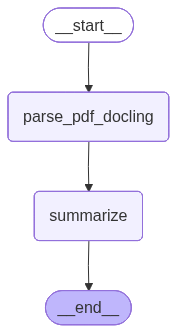

In [15]:
graph2 = StateGraph(GraphState)
graph2.add_node("parse_pdf_docling", parse_pdf_docling)
graph2.add_node("summarize", summarize_step2)

graph2.add_edge(START, "parse_pdf_docling")
graph2.add_edge("parse_pdf_docling", "summarize")
graph2.add_edge("summarize", END)

app_step2 = graph2.compile()
Image(app_step2.get_graph().draw_mermaid_png())

In [16]:
state2 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result2 = app_step2.invoke(state2)

In [17]:
print("[bold]--- Суммаризация (Шаг 2) ---[/bold]")
print(result2["summary"])

--- Суммаризация (Шаг 2) ---

В отчёте «Топ-10 стратегических технологических тенденций 2026 года» от компании Gartner рассматриваются ключевые 
направления развития технологий в условиях ускоряющегося темпа инноваций и рисков. Отчёт выделяет три темы, 
определяющие стратегию ведущих организаций: Архитектор — создание безопасных цифровых основ с использованием 
платформ разработки искусственного интеллекта (ИИ), суперкомпьютеров ИИ и конфиденциальных вычислений; Синтезатор —
интеграция специализированных моделей языка, многоагентных систем и физического ИИ для создания адаптивных 
экосистем; Вангард — повышение доверия через превентивную кибербезопасность, цифровое происхождение, платформы 
безопасности ИИ и геопатриацию данных.

Отчёт подчёркивает необходимость принятия решений руководителями высшего звена и предлагает конкретные действия для
реализации этих стратегий, включая пилотирование новых технологий, внедрение стандартов управления данными и 
разработку гибких архитектур инфраструктуры. Основной посыл заключается в том, что успешная трансформация бизнеса 
требует комплексного подхода к технологиям, который сочетает безопасность, масштабируемость и адаптируемость для 
достижения устойчивого роста и конкурентного преимущества в мире, управляемом искусственным интеллектом.

Также неудовлетворительный результат.

Итог: найдено 0 метрик из 18

---

# Шаг 3. Добавляем извлечение метрик — второй навык агента

Агент получает вторую способность — **извлечение метрик**. Добавляем новое поле `report_md` в состояние и новый узел `extract_metrics`.

**Обратите внимание:**
- Расширяем `GraphState` новым полем — так агент «учится» новому навыку
- Граф остаётся линейным: парсинг → суммаризация → метрики (последовательно)
- Используем базовый промпт для метрик (`prompt_notebook_lm`), чтобы установить baseline
- Для метрик будем сравнивать результат с эталоном через CSV-таблицу

**Граф:**
```
parse_pdf_docling → summarize → extract_metrics → END
```

In [18]:
# Расширяем состояние: добавляем поле для результата извлечения метрик
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    report_md: str          # НОВОЕ: результат извлечения метрик

In [19]:
# Узел извлечения метрик с базовым промптом
def extract_metrics_basic(state: GraphState) -> Dict[str, Any]:
    message = [
        SystemMessage(content=prompt_notebook_lm),
        HumanMessage(content=state['doc_markdown']),
    ]
    result = llm.invoke(message)
    return {"report_md": result.content}

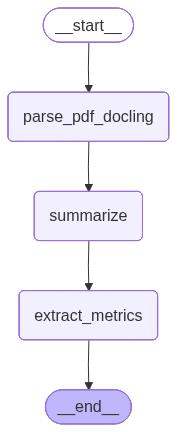

In [20]:
graph3 = StateGraph(GraphState)
graph3.add_node("parse_pdf_docling", parse_pdf_docling)
graph3.add_node("summarize", summarize_step2)
graph3.add_node("extract_metrics", extract_metrics_basic)

graph3.add_edge(START, "parse_pdf_docling")
graph3.add_edge("parse_pdf_docling", "summarize")
graph3.add_edge("summarize", "extract_metrics")
graph3.add_edge("extract_metrics", END)

app_step3 = graph3.compile()
Image(app_step3.get_graph().draw_mermaid_png())

In [21]:
state3 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result3 = app_step3.invoke(state3)

In [22]:
print("[bold]--- Суммаризация (Шаг 3) ---[/bold]")
print(result3["summary"])
print()
print("[bold]--- Метрики (Шаг 3) ---[/bold]")
print(result3["report_md"])

--- Суммаризация (Шаг 3) ---

Отчёт "Топ-10 стратегических технологических тенденций 2026 года" от компании Gartner представляет собой 
руководство для лидеров технологий в эпоху стремительных изменений, инноваций и рисков. В отчёте подчеркивается 
необходимость перехода к архитектуре, синтезу и защите доверия как ключевых тем, определяющих стратегию компаний в 
будущем.

Основные тенденции включают:

- **Архитектура**: создание безопасных, масштабируемых и адаптивных цифровых основ с использованием платформ 
разработки на основе искусственного интеллекта (ИИ), суперкомпьютеров ИИ и конфиденциальных вычислений.
- **Синтезист**: интеграция специализированных моделей языка, многоагентных систем и физического ИИ для создания 
инновационных решений.
- **Вангардец**: повышение уровня доверия через превентивную кибербезопасность, цифровое происхождение, платформы 
безопасности ИИ и геопатриацию данных.

Для практического применения отчет предлагает конкретные шаги и планы действий для каждого направления, включая 
пилотирование новых технологий, внедрение стандартов совместимости и подготовку команд к изменениям. Основной посыл
отчета заключается в том, что успешная трансформация требует не только технологического обновления, но и 
стратегической переориентации руководства, направленной на ускорение инноваций, укрепление устойчивости и защиту 
репутации организации.

--- Метрики (Шаг 3) ---

В представленном тексте нет явных числовых или других измеримых показателей ("метрик"), которые можно было бы четко
классифицировать на основе предложенных вами категорий. Вместо этого текст содержит описание стратегий, технологий 
и действий, направленных на развитие бизнеса и защиту данных в эпоху искусственного интеллекта и 
гиперподключенности. Однако можно выделить несколько ключевых тем и направлений для возможного анализа, если 
рассматривать их как потенциальные области измерения эффективности.

### Возможная классификация по категориям:

#### **Связанные с технологиями и платформами**
- Использование AI Native Development Platforms 
- Внедрение AI Supercomputing Platforms
- Применение Confidential Computing
- Развертывание Multiagent Systems
- Внедрение Domain-Specific Language Models
- Интеграция Physical AI

**Примеры возможных метрик**:  
- Количество успешно реализованных проектов с использованием AI native development platforms  
- Уровень использования вычислительных мощностей AI суперкомпьютеров  
- Уровни защиты конфиденциальной информации при использовании конфиденциального вычисления  
- Эффективность работы мультиагентных систем в реальных условиях  
- Качество моделей специализированных языков программирования  
- Производительность физической реализации ИИ-систем

---

#### **Связанные с безопасностью и доверием**
- Предупреждающая кибербезопасность (Preemptive Cybersecurity)
- Цифровая прослеживаемость (Digital Provenance)
- Платформы безопасности ИИ (AI Security Platforms)
- Геопатриация (Geopatriation)

**Примеры возможных метрик**:  
- Сокращение времени реагирования на угрозы благодаря предупреждающей кибербезопасности  
- Процент защищённых активов через цифровую прослеживаемость  
- Снижение рисков утечек данных с помощью платформ безопасности ИИ  
- Скорость миграции критических рабочих нагрузок в соответствии со стратегией геопатриации

---

#### **Связанные с управлением и стратегическим планированием**
- Определение стратегии AI First  
- Создание команд платформы и внедрение стандартов безопасности  
- Пилотирование новых решений и мониторинг результатов  
- Формулирование планов внедрения и развития цифровых основ

**Примеры возможных метрик**:  
- Время принятия стратегических решений относительно цифровой трансформации  
- Степень интеграции инновационных подходов в повседневные процессы компании  
- Показатели успеха пилотных проектов  
- Рост уровня осведомленности сотрудников о современных технологиях и подходах к управлению рисками

---

Таким образом, хотя документ не содержит конкретных чисел или явно выраженных метрик, он предоставляет достаточно 
контекста для того, чтобы разработать систему оценки эффективности внедрений и мероприятий, связанных с указанными 
выше категориями.

In [10]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_3.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 3

,Категория метрики,Метрики из отчета Notebook_lm,Есть ли метрика в отчете Гига,Метрики Гигачата
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,—
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,—
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,—
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,Процент защищенных данных при использовании ко...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,Использование гибридных облачных архитектур дл...
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Нет,—
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,Темп миграции рабочих нагрузок в суверенные об...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,—


Итог: найдено 3 метрик из 18

---

# Шаг 4. Улучшенный промпт для метрик

Та же архитектура, но улучшенный промпт для метрик. Применяем тот же урок, что и на шагах 1→2: **промпт-инжиниринг** кардинально улучшает качество без изменения графа.

**Обратите внимание:**
- Новый промпт задаёт роль аналитика кибербезопасности
- Требует обязательные числовые значения у метрик
- Определяет структурированный формат вывода с примером
- Суммаризация не меняется — изолируем вклад именно промпта метрик
- Используем **фабричную функцию** `make_extract_metrics` для создания узла с фиксированным промптом

**Граф:** тот же, что в шаге 3.

In [24]:
show_prompt(new_prompt, title="Улучшенный промпт метрик (Шаг 4)")

╭─────────────────────────────────────── Улучшенный промпт метрик (Шаг 4) ────────────────────────────────────────╮
│                                                                                                                 │
│  Ты специалист по кибербезопасности, который занимается профессиональной публицистикой и глубоким анализом      │
│  аналитических отчетов в сфере кибербезопасности.                                                               │
│  Проанализируй документ ниже и найди метрики (временные, количественные, качественные).                         │
│  Метрики могут быть либо явно указаны в тексте документа, либо сформулированы тобой исходя описания возможных   │
│  изменений (рост, снижение, изменение интенсивности чего-либо и т.д.).                                          │
│  Метрики ОБЯЗАТЕЛЬНО должны выражаться какими-то числовыми значениями. Если есть какое-то описание метрики, но  │
│  нет цифрового выражения, то эту метрику описывать не нужно.                                                    │
│  Для каждой метрики необходимо указать краткое емкое название и описание, что именно метрика показывает         │
│  (исходное в тексте либо сформулированное тобой) в описании обязательно должно быть цифровое выражение этой     │
│  метрики.                                                                                                       │
│  Обрати внимание, что метрики могут быть временные, количественные, качественные. Необходимо найти и описать    │
│  ВСЕ метрики, упомянутые в документе. В случае отсутствия метрик укажи "Отчет не содержит метрик". Если         │
│  метрики найдены, сгруппируй по призканам. Примеры признаков:                                                   │
│      связанные с кибер атаками                                                                                  │
│      связанные с защитой кибер периметра                                                                        │
│      связанные с сетью                                                                                          │
│      связанные с системами                                                                                      │
│      связанные с бизнес процессами.                                                                             │
│  Не обязательно придерживаться именно такой классификации. Используй ее как отправную точку и пример. Если      │
│  поймешь, что метрики группируются по другим признакам, то можешь добавить новые признаки.                      │
│  Формат вывода: нумерованный список групп метрик. В каждой групп ненумерованный список метрик, входящих в эту   │
│  группу.                                                                                                        │
│  Формат вывода метрик: "Название метрики: Описание метрики вместе с числовыми показателями".                    │
│  Пример:                                                                                                        │
│  "1. Метрики, связанные с киберугрозами и атаками                                                               │
│      - Количество уязвимостей: Ожидается, что число задокументированных уязвимостей превысит 100 ежегодно к     │
│  2028 году.                                                                                                     │
│      - Природа угроз ИИ: 90% несанкционированных транзакций ИИ будут связаны с нарушениями политик              │
│  безопасности, а не с внешними атаками."                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

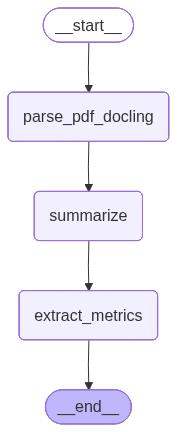

In [25]:
extract_metrics_improved = make_extract_metrics(new_prompt)

graph4 = StateGraph(GraphState)
graph4.add_node("parse_pdf_docling", parse_pdf_docling)
graph4.add_node("summarize", summarize_step2)
graph4.add_node("extract_metrics", extract_metrics_improved)

graph4.add_edge(START, "parse_pdf_docling")
graph4.add_edge("parse_pdf_docling", "summarize")
graph4.add_edge("summarize", "extract_metrics")
graph4.add_edge("extract_metrics", END)

app_step4 = graph4.compile()
Image(app_step4.get_graph().draw_mermaid_png())

In [26]:
state4 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
result4 = app_step4.invoke(state4)

In [27]:
print("[bold]--- Суммаризация (Шаг 4) ---[/bold]")
print(result4["summary"])
print()
print("[bold]--- Метрики (Шаг 4) ---[/bold]")
print(result4["report_md"])

--- Суммаризация (Шаг 4) ---

В отчёте "Top 10 Strategic Technology Trends for 2026" от компании Gartner за 2026 год представлены стратегические 
направления технологий, которые станут катализаторами трансформации бизнеса в условиях искусственного интеллекта и 
гиперподключённого мира. Отчёт выделяет три ключевые темы инноваций: создание безопасных цифровых основ 
("Архитект"), синтезирование различных технологий для создания новых источников ценности ("Синтезист") и повышение 
доверия через безопасность и управление рисками ("Авангард").

Ключевые тренды включают:

- Платформы разработки с поддержкой ИИ;
- Суперкомпьютеры для задач искусственного интеллекта;
- Конфиденциальные вычисления;
- Мультиагентные системы;
- Специализированные языковые модели;
- Физический искусственный интеллект;
- Предупреждающая кибербезопасность;
- Цифровое происхождение;
- Площадки безопасности для искусственного интеллекта;
- Геопатриотизация данных.

Для руководителей предлагаются конкретные действия по внедрению этих тенденций, такие как пилотирование платформ 
разработки с использованием ИИ, внедрение суперкомпьютерных решений, использование доверенных вычислительных сред, 
а также развитие многоагентных систем и специализированных моделей языка.

Основной посыл отчета заключается в том, что успешная трансформация требует не только внедрения отдельных 
технологий, но и интеграции их в общую стратегию предприятия, обеспечивая при этом доверие, безопасность и 
устойчивость к изменениям.

--- Метрики (Шаг 4) ---

1. Метрики, связанные с технологиями искусственного интеллекта
    - Процент предприятий, использующих гибридные вычислительные архитектуры: К 2028 году ожидается, что 40% 
предприятий перейдут на использование гибридных архитектур вычислений (по сравнению с текущими 8%).
    - Число поставщиков платформ для разработчиков, использующие суперкомпьютерные среды: Более 20 поставщиков 
предложат унифицированные платформы разработки, поддерживающие суперкомпьютинговые среды до 2028 года.
    - Рост запросов на системы многоагентного взаимодействия: Отмечается рост числа запросов от клиентов о системах
многоагентного взаимодействия на 1445% за период с первого квартала 2024 года по второй квартал 2025 года.
    - Доля ведущих производителей решений на базе физического искусственного интеллекта: К 2028 году пять из десяти
крупнейших компаний-производителей систем искусственного интеллекта предложат продукты на основе физической 
реализации искусственного интеллекта.

2. Метрики, связанные с безопасностью информационных технологий
    - Потеря актуальности продуктов без превентивной кибербезопасности: К 2029 году технология или продукт, не 
обеспечивающий превентивную защиту от кибератак, потеряет свою рыночную значимость.

3. Метрики, связанные с разработкой программного обеспечения
    - Производительность команд при использовании платформ разработки на основе искусственного интеллекта: Пять 
небольших команд смогут одновременно разрабатывать пять приложений благодаря использованию инструментов на основе 
искусственного интеллекта, позволяющих ускорить разработку программных продуктов.

4. Метрики, связанные с управлением данными и их защищенностью
    - Уровень защиты данных во время обработки: Использование конфиденциальных вычислений позволяет защитить данные
даже в облачных средах, обеспечивая соответствие требованиям конфиденциальности и локализации данных.

Отчет не содержит других явных метрик.

In [ ]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_4.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 5

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,'-
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,Уровень защиты данных во время обработки: испо...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Да,"К 2029 году технология или продукт, не обеспеч..."
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"К 2028 году ожидается, что 40% предприятий пер..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,Более 20 поставщиков предложат унифицированные...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,'-
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


Итог: 5 метрик из 18

---

# Шаг 5. Map-Reduce: постраничное извлечение метрик + параллельная суммаризация

Главное архитектурное изменение: вводим паттерн **Map-Reduce** для извлечения метрик. Каждая страница обрабатывается независимо и параллельно (map), затем результаты объединяются (reduce). Это решает проблему **«lost-in-the-middle»** для длинных документов.

Суммаризация остаётся единым вызовом LLM на весь документ — и запускается **параллельно** с постраничной обработкой метрик.

**Обратите внимание:**
- `Send` — динамический fan-out: создаёт по одному экземпляру узла на каждую страницу
- `Annotated[List[...], operator.add]` — автоматический reducer для сбора результатов параллельных узлов
- При `max_concurrency=4` суммаризация занимает 1 слот кратковременно, а постраничные воркеры используют оставшиеся 3 (затем все 4 после завершения суммаризации)
- LangGraph автоматически ждёт завершения **всех** рёбер в END

**Граф:**
```
parse_pdf_docling ─┬→ summarize ──────────────────────────────────────────→ END
                   └→ prepare_pages → [fanout] → extract_metrics_page × N → reduce_reports → END
```

In [16]:
# Расширяем состояние: добавляем поля для map-reduce
class GraphState(TypedDict, total=False):
    pdf_path: str
    doc_id: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    # map-reduce поля:
    pages: List[Dict[str, Any]]                                    # [{page_no: int, md: str}, ...]
    page_metrics: Annotated[List[Dict[str, Any]], operator.add]    # reducer: автоматически накапливает
    report_md: str

In [28]:
def prepare_pages(state: GraphState) -> Dict[str, Any]:
    # Разбиваем документ в md формате на страницы по маркеру <!-- PAGE_BREAK -->
    pages_md = [{"page_no": i, "md": x.strip()}
                for i, x in enumerate(state["doc_markdown"].split("<!-- PAGE_BREAK -->"))
                if x.strip()]
    return {"pages": pages_md, "page_metrics": []}


def fanout_pages(state: GraphState):
    # На каждую страницу создаём отдельный запуск узла-воркера — распараллеливаем процесс
    return [
        Send("extract_metrics_page", {"page": page})
        for page in state["pages"]
    ]


def extract_metrics_page(state: Dict[str, Any]) -> Dict[str, Any]:
    """Извлекаем метрики для одной страницы. Запускается параллельно для всех страниц."""
    page = state["page"]
    messages = [
        SystemMessage(content=new_prompt),
        HumanMessage(content=f'Документ:\n{page["md"]}'),
    ]
    result = llm.invoke(messages)
    return {
        "page_metrics": [{"page_no": page["page_no"], "summary": result.content}]
    }


def reduce_reports(state: GraphState) -> Dict[str, Any]:
    """Объединяем результаты работы LLM по всем страницам в один отчет."""
    items = state.get("page_metrics", [])
    # Сортируем по page_no, потому что параллельные апдейты могут прийти в разном порядке
    items = sorted(items, key=lambda x: (x.get("page_no") is None, x.get("page_no")))
    combined = "\n\n".join(
        i['summary'] for i in items if 'Отчет не содержит' not in i["summary"]
    )
    return {"report_md": combined}

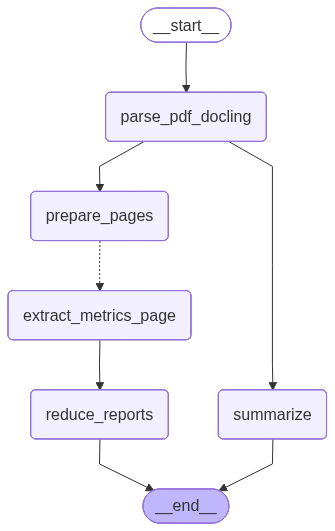

In [23]:
graph5 = StateGraph(GraphState)
graph5.add_node("parse_pdf_docling", parse_pdf_docling)
graph5.add_node("summarize", summarize_step2)
graph5.add_node("prepare_pages", prepare_pages)
graph5.add_node("extract_metrics_page", extract_metrics_page)
graph5.add_node("reduce_reports", reduce_reports)

graph5.add_edge(START, "parse_pdf_docling")
# После парсинга — две параллельные ветки
graph5.add_edge("parse_pdf_docling", "summarize")
graph5.add_edge("parse_pdf_docling", "prepare_pages")
# map step: динамический fan-out
graph5.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
# reduce step: fan-in в один узел
graph5.add_edge("extract_metrics_page", "reduce_reports")
# Обе ветки сходятся в END
graph5.add_edge("summarize", END)
graph5.add_edge("reduce_reports", END)

app_step5 = graph5.compile()
Image(app_step5.get_graph().draw_mermaid_png())

In [24]:
state5 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config5 = {"max_concurrency": 3}
result5 = app_step5.invoke(state5, config5)

In [25]:
print("[bold]--- Суммаризация (Шаг 5) ---[/bold]")
print(result5["summary"])
print()
print("[bold]--- Метрики (Шаг 5) ---[/bold]")
print(result5["report_md"])

--- Суммаризация (Шаг 5) ---

В отчёте "Top 10 Strategic Technology Trends for 2026" от компании Gartner за 2026 год рассматриваются ключевые 
тенденции в области технологий, которые станут катализаторами бизнес-трансформации. Отчёт разделён на три темы: 
Архитектор (создание безопасных цифровых основ с использованием платформ разработки на основе ИИ, суперкомпьютеров 
и конфиденциальных вычислений); Синтезатор (интеграция специализированных моделей языка, мультиагентных систем и 
физического искусственного интеллекта); Вангард (повышение доверия через превентивную кибербезопасность, цифровое 
происхождение, платформы безопасности ИИ и геопатриацию данных).

Среди ключевых технологических тенденций выделяются:

- Платформы разработки на базе ИИ;
- Суперкомпьютерные платформы на базе ИИ;
- Конфиденциальные вычисления;
- Мультиагентные системы;
- Специализированные языковые модели;
- Физический искусственный интеллект;
- Превентивная кибербезопасность;
- Цифровое происхождение;
- Платформы безопасности ИИ;
- Геопатриация данных.

Для практического внедрения этих тенденций руководителям рекомендуется определить стратегию, внедрить меры 
управления рисками, обеспечить соблюдение нормативных требований и инвестировать в обучение сотрудников новым 
технологиям. Основной посыл отчета заключается в том, что успешная реализация перечисленных стратегий позволит 
организациям не только защитить свои активы, но и повысить конкурентоспособность и устойчивость к внешним вызовам.

--- Метрики (Шаг 5) ---

1. Метрики, связанные с развитием технологий искусственного интеллекта
    - Доля предприятий, использующих гибридные вычислительные архитектуры: К 2028 году ожидается рост до 40%, тогда
как на текущий момент этот показатель составляет всего 8%.
    - Число поставщиков платформ для разработчиков, использующие суперкомпьютерные среды: К 2028 году количество 
таких компаний достигнет более чем 20+.

1. Метрики, связанные с технологиями искусственного интеллекта
- Рост запросов на многоагентные системы: Отмечается рост на 1,445% от первого квартала 2024 года до второго 
квартала 2025 года.

In [26]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_5.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 4

,Название категории метрики,Метрики из 1 отчета,Есть ли метрика в отчете Гига,Метрики из второго отчета
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,'-
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,'-
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,'-
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,'-
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'-
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Да,Потеря рыночной значимости продуктов без преве...
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"m001: % предприятий, использующих гибридные вы..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,m002: Количество поставщиков платформ для разр...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,'-
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,'-


Итог: 4 метрики из 18

---

# Шаг 6. Добавляем парсинг изображений

Меняем только **один узел**: парсер PDF теперь анализирует изображения через GigaChat. Диаграммы, схемы и графики, которые Docling заменял на `<!-- image -->`, теперь описываются текстом и вставляются в markdown.

**Обратите внимание:**
- Обогащённый текст попадает **и** в суммаризацию, **и** в извлечение метрик
- Архитектура графа идентична шагу 5 — изолируем вклад именно анализа изображений
- `make_parse_pdf_gigachat_postprocess` — фабричная функция: парсит PDF, для каждого `<!-- image -->` вызывает GigaChat, заменяет плейсхолдер описанием (строго 1:1)
- Шаг работает значительно **дольше** из-за вызовов GigaChat для каждого изображения

**Граф:** тот же, что в шаге 5, но узел парсинга заменён на image-aware версию.

In [166]:
# Фабрика возвращает функцию-узел с зафиксированным промптом для анализа изображений


parse_with_gigachat_images = make_parse_pdf_gigachat_postprocess(prompt=IMAGE_ANALYSIS_PROMPT)

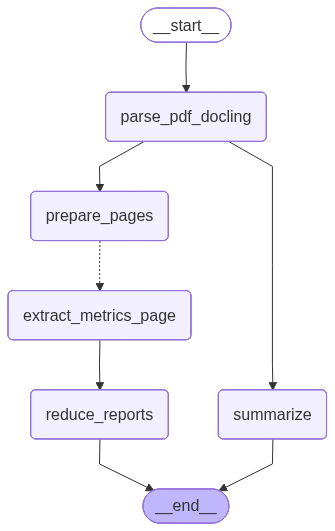

In [28]:
# Граф идентичен шагу 5 — единственное отличие: узел парсинга заменён на image-aware версию
graph6 = StateGraph(GraphState)
graph6.add_node("parse_pdf_docling", parse_with_gigachat_images)  # ← единственное отличие от шага 5
graph6.add_node("summarize", summarize_step2)
graph6.add_node("prepare_pages", prepare_pages)
graph6.add_node("extract_metrics_page", extract_metrics_page)
graph6.add_node("reduce_reports", reduce_reports)

graph6.add_edge(START, "parse_pdf_docling")
graph6.add_edge("parse_pdf_docling", "summarize")
graph6.add_edge("parse_pdf_docling", "prepare_pages")
graph6.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
graph6.add_edge("extract_metrics_page", "reduce_reports")
graph6.add_edge("summarize", END)
graph6.add_edge("reduce_reports", END)

app_step6 = graph6.compile()
Image(app_step6.get_graph().draw_mermaid_png())

In [29]:
state6 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config6 = {"max_concurrency": 2}
result6 = app_step6.invoke(state6, config6)

In [30]:
print("[bold]--- Суммаризация (Шаг 6) ---[/bold]")
print(result6["summary"])
print()
print("[bold]--- Метрики (Шаг 6) ---[/bold]")
print(result6["report_md"])

--- Суммаризация (Шаг 6) ---

Отчет Gartner за 2026 год посвящен стратегическим технологиям, способствующим бизнес-трансформации и повышению 
конкурентоспособности компаний в мире, управляемом искусственным интеллектом и гиперподключенностью. Ключевые темы 
включают создание безопасной цифровой инфраструктуры («Архитектура»), интеграцию специализированных технологий 
(«Синтезатор») и повышение доверия и надежности («Передовой отряд»).

Основные тренды и концепции отчета:

- Специализированные языковые модели и мультиагентные системы;
- Конфиденциальные вычисления и физические системы искусственного интеллекта;
- Предупреждающая кибербезопасность и цифровое происхождение;
- Платформы безопасности на базе искусственного интеллекта и геопатризация данных.

Руководителям рекомендуется предпринять конкретные шаги для внедрения этих технологий, такие как аудит критических 
областей бизнеса, пилотирование новых решений и формирование кросс-функциональных команд. Основной посыл отчета 
заключается в том, что успешные организации должны активно реагировать на изменения, интегрируя эти стратегии в 
свои планы для устойчивого роста и повышения конкурентного преимущества.

--- Метрики (Шаг 6) ---

1. Метрики, связанные с безопасностью данных и технологиями конфиденциальности:
    - Доля обработанных данных под защитой конфиденциальных вычислений: К 2029 году ожидается, что 75% всех 
операций с данными, проводимых в доверенных инфраструктурах, будут защищены при помощи технологий конфиденциальных 
вычислений.

1. Количественные метрики роста интереса к мультиагентным системам
   - Рост запросов о мультиагентных системах: Отмечается рост на 1,445% от первого квартала 2024 года до второго 
квартала 2025 года.
   
2. Прогнозируемые процентные показатели использования мультиагентных систем
   - Использование специализированных агентов: 70% всех мультиагентных систем будет использовать специализированные
агенты к 2027 году.
   - Поддержка многоплатформенной интероперабельности: 60% всех мультиагентных систем будет поддерживать 
многоплатформенную интероперабельность к 2028 году.

1. Метрики, связанные с развитием технологий искусственного интеллекта:
    - Процент доменно-специфичных моделей GenAI: К 2028 году ожидается рост до +60%.
    - Процент рабочих нагрузок GenAI работающих с DLSL на локальных серверах или устройствах: К 2028 году будет 
составлять 30%.

1. Метрики, связанные с развитием технологий физического ИИ
    - Доля поставщиков физических решений ИИ среди ведущих производителей: К 2028 году пять из десяти крупнейших 
поставщиков систем искусственного интеллекта предложат решения физического ИИ.
    - Уровень внедрения роботизированных и автоматизированных решений на складах: К 2028 году 80% складов внедрят 
роботизированные системы или другие формы автоматизации.

1. Метрики, связанные с принятием технологий ИИ для обеспечения безопасности:
    - Доля компаний, использующих ИИ в качестве основного инструмента безопасности: +50% предприятий примут ИИ в 
качестве основного средства безопасности к 2028 году.
    
2. Метрики, связанные с природой угроз ИИ:
    - Процент несанкционированных транзакций ИИ: 80% несанкционированных транзакций с использованием ИИ будут 
происходить из-за внутренних нарушений, а не внешних атак.

In [33]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_6.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 6

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,—
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Да,80% несанкционированных транзакций с использов...
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,—
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,"75% всех операций с данными, проводимых в дове..."
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,'+50% предприятий примут ИИ в качестве основно...
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Нет,—
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Нет,—
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Нет,—
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Да,"Процент рабочих нагрузок GenAI, работающих с D..."


Необходимо также учитывать шибки перплексити при оценке и NotebookLM при составлении отчета по метрикам:
- 4 пункт перплексити не видит в отчете, хотя агент нашел эту метрику (Доля компаний, использующих ИИ в качестве основного инструмента безопасности: +50% предприятий примут ИИ в 
качестве основного средства безопасности к 2028 году.).
- 15 пункт можно считать верным, т.к. NotebookLM ошибается, в отчете фигурирует показатель в 60% (стр. 14 отчета), NotebookLM прочитал эту метрику как 50%.

Итого: 8 метрик из 18. 

---

# Шаг 7. Полный документ с изображениями

Возвращаемся к анализу документа **целиком** (без map-reduce), но сохраняем парсинг изображений. И суммаризация, и метрики видят полный документ с описаниями изображений — **максимальный контекст**.

**Обратите внимание:**
- Оба вызова — одиночные запросы к LLM, поэтому запускаем их **параллельно** от узла парсинга

- Граф максимально простой — три узла, две параллельные ветки

**Граф:**
```
parse_pdf_docling ─┬→ summarize ──────→ END
                   └→ extract_metrics → END
```

In [44]:
# Упрощаем состояние: map-reduce поля больше не нужны
class GraphState(TypedDict, total=False):
    pdf_path: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    report_md: str

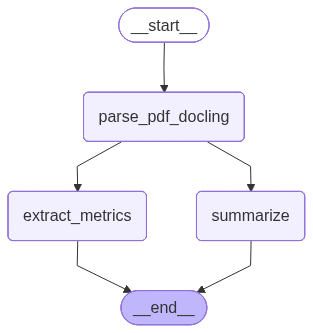

In [62]:
from blanks.prompts import structured_sys

extract_metrics_node = make_extract_metrics(new_prompt)

graph7 = StateGraph(GraphState)
graph7.add_node("parse_pdf_docling", parse_with_gigachat_images)
graph7.add_node("summarize", summarize_step2)
graph7.add_node("extract_metrics", extract_metrics_node)

graph7.add_edge(START, "parse_pdf_docling")
# Две параллельные ветки от парсинга
graph7.add_edge("parse_pdf_docling", "summarize")
graph7.add_edge("parse_pdf_docling", "extract_metrics")
graph7.add_edge("summarize", END)
graph7.add_edge("extract_metrics", END)

app_step7 = graph7.compile()
Image(app_step7.get_graph().draw_mermaid_png())

In [63]:
state7 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config7 = {"max_concurrency": 1}
result7 = app_step7.invoke(state7, config7)

In [ ]:
print("[bold]--- Суммаризация (Шаг 7) ---[/bold]")
print(result7["summary"])
print()
print("[bold]--- Метрики (Шаг 7) ---[/bold]")
print(result7["report_md"])

--- Суммаризация (Шаг 7) ---

Отчет Gartner за 2026 год посвящен стратегическим технологиям, определяющим вектор развития бизнеса в эпоху 
гиперподключенности и искусственно-интеллектуального ускорения. Технологические лидеры сталкиваются с 
необходимостью трансформации бизнес-моделей, учитывая растущие угрозы и возможности, создаваемые развитием 
ИИ-технологий.

Ключевые темы отчета включают:

1. Архитектура – создание устойчивых и адаптивных цифровых основ посредством AI Native Development Platforms, AI 
Supercomputing и Confidential Computing.
   
2. Синтезатор – интеграция специализированных языковых моделей, мультиагентных систем и физического ИИ для открытия
новых источников ценности.
   
3. Авангард – повышение доверия и прозрачности путем внедрения предиктивной кибербезопасности, цифровой пруванс, 
платформ безопасности ИИ и гео-патриотизации данных.

Практически ориентированные рекомендации предлагают руководителям конкретные шаги по внедрению этих тенденций, 
включая пилотирование инновационных решений, разработку дорожной карты и усиление сотрудничества между 
ИТ-подразделениями и бизнесом.

Основной посыл отчета заключается в том, что успешные организации будущего должны активно инвестировать в эти 
направления, чтобы оставаться конкурентоспособными и устойчивыми в условиях ускоряющихся изменений.

--- Метрики (Шаг 7) ---

1. Метрики, связанные с технологиями разработки и инфраструктуры
    - Процент организаций, использующих tiny teams: Ожидается, что к 2030 году 80% организаций перейдут на small, 
AI-augmented команды разработчиков вместо крупных инженерных коллективов.
    - Доля портфеля приложений, построенных на AI-native платформах: Ожидается рост с 2% в 2025 г. до 40% в 2030 г.
    - Рост числа запросов по мультиинтеллектуальным агентским системам: Зафиксирован резкий скачок на 1445%, 
сигнализирующий о растущем интересе среди компаний.
    - Уровень применения гибридных архитектур: До 40% предприятий внедрят гибридные архитектуры к 2028 году против 
текущих 8%.
    - Объем предложений платформ с поддержкой суперкомпьютерного окружения: Более 20 производителей предложат 
унифицированные платформы к 2028 году.
    - Доменно-ориентированные языковые модели: К 2028 году около 60% генеративно-искусственных интеллектов станут 
специализированными.
    - Локализация критически важных цифровых активов: 75% компаний планируют реализовать стратегию локализации 
своих цифровых активов к 2030 году.

2. Метрики, связанные с искусственным интеллектом и его применением
    - Применение физического ИИ: К 2028 году половина ведущих поставщиков ИИ предложит продукты физического ИИ.
    - Роль ИИ в защите данных: Ожидается, что к 2028 году 50% бюджета на безопасность будет направлено на системы 
предиктивного предотвращения угроз.
    - Задокументированные уязвимости: Их количество достигнет миллиона ежегодно уже к 2030 году.

3. Метрики, связанные с кибербезопасностью
    - Предсказуемость угрозы: 80% несанкционированных трансакций с участием ИИ окажутся следствием внутреннего 
нарушения политики безопасности, а не внешней атаки.
    - Стратегия геопатиации: 75% предприятий перенесут свои рабочие нагрузки в суверенные облака к 2030 году.

4. Метрики, связанные с бизнесом и финансированием
    - Инвестиционная стратегия: Компании постепенно переходят от покупки готовых решений к самостоятельному 
созданию собственных продуктов благодаря AI-native инструментам.
    - Бюджетирование: Финансовые подразделения адаптируют финансирование под нужды внедрения новых стратегий, таких
как AI native development, MAS и другие технологии.

Эти метрики позволяют оценить изменения в технологиях и подходах, используемых компаниями, и дают представление о 
масштабах трансформации в области ИТ и бизнеса.

In [34]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_7.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 9

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Да,Задокументированные уязвимости: Их количество ...
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Да,Предсказуемость угрозы: 80% несанкционированны...
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Да,"Роль ИИ в защите данных: Ожидается, что к 2028..."
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Нет,—
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,Уровень применения гибридных архитектур: До 40...
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,Объем предложений платформ с поддержкой суперк...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,Стратегия геопатиации: 75% предприятий перенес...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,—


Так же, как и в предыдущем пункте, у оценщика перплексити и у NotebookLM суммарно ошибки в 2-ух пунктах (4-ый и 15-ый не защитаны, хотя агент их нашел верно).  

Итого: 11 метрик из 18. 

---

# Шаг 8. Параллельные постраничный парсинг со структурированным промптом

Возвращаемся к анализу документа **постранично**, но теперь добавим в `extract_metrics` промпт для вывода метрик в виде JSON и далее попросим LLM вывести метрики в виде изображений.

**Обратите внимание:**
- extract_metrics — два последовательных вызова LLM
- Это **продакшен-конфигурация**: лучшее качество и эффективное параллельное выполнение
- добавляем ноду критика и финальный суммарайзер для хранения отчетов


**Граф:**
```
parse_pdf_docling ─┬→ summarize ──────→ END
                   └→ extract_metrics(→ LLM(structured_output) → LLM(перепиши в виде предложения))  → END
```

In [54]:
# Расширяем состояние: добавляем поля для критика
class GraphState(TypedDict, total=False):
    pdf_path: str
    doc_id: str
    docling_doc: DoclingDocument
    doc_markdown: str
    summary: str
    # map-reduce поля:
    pages: List[Dict[str, Any]]                                    # [{page_no: int, md: str}, ...]
    page_metrics: Annotated[List[Dict[str, Any]], operator.add]    # reducer: автоматически накапливает
    report_md: str

In [55]:
def extract_metrics_page(state: Dict[str, Any]) -> Dict[str, Any]:
    """Извлекаем метрики для одной страницы. Запускается параллельно для всех страниц."""
    page = state["page"]
    messages = [
        SystemMessage(content=structured_sys),
        HumanMessage(content=f'Документ:\n{page["md"]}'),
    ]

    result = parse_llm.invoke(messages)

    messages = [
        SystemMessage(content="Тебе на вход даны метрики в структурированном виде, перепиши данные метрики в виде предложений." \
        " Точность важнее полноты. Если метрик в докумете нет, ответь ''."),
        HumanMessage(content=f'Документ:\n{result.content}'),
    ]
    result = parse_llm.invoke(messages)


    return {
        "page_metrics": [{"page_no": page["page_no"], "summary": result.content if result.content else ''}]
    }



def reduce_reports(state: GraphState) -> Dict[str, Any]:
    """Объединяем результаты работы LLM по всем страницам в один отчет."""
    items = state.get("page_metrics", [])
    # Сортируем по page_no, потому что параллельные апдейты могут прийти в разном порядке
    items = sorted(items, key=lambda x: (x.get("page_no") is None, x.get("page_no")))
    combined = "\n\n".join(
                    [p['summary'] for p in state['page_metrics'] if "''" not in p['summary']]
                        )
    
    messages = [
        SystemMessage(content="Тебе даны извлеченные метрики из отчета <metrics>." \
        " Составь из этих метрик отчет максимально точно, с указанием всех метрик, их показателей, сроков и тд." \
        "Посчитай количество метрик, а затем проверь, чтобы все метрики вошли в отчет."),
        HumanMessage(content=f"<metrics>: {combined}, <report>: {state['doc_markdown']}"),
    ]
    result_rep = llm.invoke(messages)


    return {"report_md": result_rep.content}




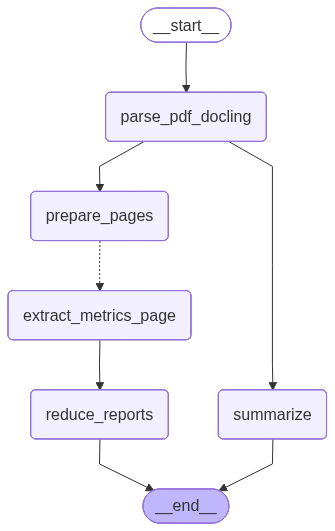

In [56]:
# Граф идентичен шагу 6 — единственное отличие: используем структурированный промпт
graph8 = StateGraph(GraphState)
graph8.add_node("parse_pdf_docling", parse_with_gigachat_images)  # ← единственное отличие от шага 5
graph8.add_node("summarize", summarize_step2)
graph8.add_node("prepare_pages", prepare_pages)
graph8.add_node("extract_metrics_page", extract_metrics_page)
graph8.add_node("reduce_reports", reduce_reports)

graph8.add_edge(START, "parse_pdf_docling")
graph8.add_edge("parse_pdf_docling", "summarize")
graph8.add_edge("parse_pdf_docling", "prepare_pages")
graph8.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
graph8.add_edge("extract_metrics_page", "reduce_reports")
graph8.add_edge("summarize", END)
graph8.add_edge("reduce_reports", END)

app_step8 = graph8.compile()
Image(app_step8.get_graph().draw_mermaid_png(max_retries=5))

In [57]:
state8 = GraphState(pdf_path="input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf")
config8 = {"max_concurrency": 3}
result8 = app_step8.invoke(state8, config8)

In [ ]:
print("[bold]--- Суммаризация (Шаг 8) ---[/bold]")
print(result8["summary"])
print()


In [58]:
print("[bold]--- Метрики (Шаг 8) ---[/bold]")
print(result8['report_md'])

--- Метрики (Шаг 8) ---

# Отчет по ключевым показателям эффективности

Данный отчет основан на предоставленных метриках и предназначен для предоставления полного обзора текущих 
показателей деятельности организации. Каждый показатель детально описан ниже вместе с его контекстом и направлением
изменения.

---

## Основные показатели эффективности

### Преобразование инженерных команд
- **Показатель**: К 2030 году доля организаций, трансформирующих крупные инженерные команды по разработке ПО в 
небольшие команды, поддержанные искусственным интеллектом, достигнет $80\%$.

### Корпоративный портфель приложений
- **Показатель**: Доля приложений, созданных на базе платформ AI-native, вырастет до $40\%$ к 2030 году (по 
сравнению с $2\%$ в 2025 г.).

### Гибридная архитектура
- **Показатель**: Доля компаний, использующих гибридную архитектуру, возрастёт до $40\%$ к 2028 году (текущее 
значение – $8\%$).
- **Количество поставщиков**: К 2028 году число поставщиков унифицированных платформ разработки превысит $20$ 
единиц.

### Конфиденциальные вычисления
- **Показатель**: К 2029 году $75\%$ обрабатываемых данных будут защищены конфиденциальными вычислениями.
- **Риски**: Увеличение расходов и сложности процессов; дополнительные расходы на систему управления ключами и 
сопротивление изменениям.

### Мультиагентные системы
- **Рост запросов**: За первый квартал 2024–2025 гг. рост запросов составил $1\,445\%$.
- **Ожидания**: К 2027 году $70\%$ таких систем будут использовать специализированные агенты, улучшая точность, но 
усложняя координацию.
- **Интероперабельность**: К 2028 году $60\%$ систем обеспечит взаимодействие между платформами.

### Доменно-специфические языковые модели (GenAI)
- **Доля**: К 2028 году $60\%$ корпоративных моделей GenAI станут доменно-специфическими.
- **Рабочие нагрузки**: $30\%$ рабочих нагрузок GenAI будут работать с такими моделями на локальных серверах или 
устройствах.

### Склады и робототехника
- **Использование робототехники**: К 2028 году $80\%$ складов будут применять робототехнику или автоматизацию.
- **Предложения физических решений**: К 2028 году пятеро крупнейших поставщиков решений на основе искусственного 
интеллекта представят физические решения.

### Расходы на превентивную кибербезопасность
- **Процент расходов**: К 2030 году $50\%$ средств на кибербезопасность пойдет на превентивные решения.
- **Документируемые уязвимости**: Ежегодно к 2030 году будет фиксироваться свыше миллиона уязвимостей.

### Цифровые доказательства происхождения
- **Типы контента**: Необходимо фильтровать девять различных типов контента.
- **Результат фильтрации**: Показатель успешности фильтрации отсутствует.

### Искусственный интеллект в обеспечении безопасности
- **Применение**: К 2028 году $50\%$ предприятий перейдут на использование ИИ как основного инструмента 
безопасности.
- **Причины утечек**: $80\%$ несанкционированных транзакций произойдет вследствие внутренних нарушений, а не 
внешних атак.

### Суверенные облачные среды
- **План перевода**: К 2030 году $75\%$ предприятий планируют перевод своих рабочих нагрузок в местные или 
суверенные облачные среды.
- **Развитие предложений**: Быстро расширяется ассортимент предложений суверенных облаков крупных провайдеров и 
местных поставщиков.

### Поставщики продуктов и сервисов
- **Оценка общего балла**: Средний общий балл поставщика составляет $95$ из $100$.
- **Функциональные требования**: Соответствие требованиям – $79$ баллов.
- **Технические требования**: Соответствие требованиям – $91$ балл.
- **Поддержка и услуги**: Качество обслуживания оценивается в $64$ балла.
- **Финансовая устойчивость**: Финансовая стабильность поставщика оценена в $90$ баллов.
- **Ценообразование и условия**: Коммерческие условия получают оценку $79$ баллов.

---

## Заключение

Отчёт охватывает широкий спектр важнейших показателей эффективности, включая преобразования инженерных команд, 
применение платформ AI-native, развитие гибридных архитектур, вопросы конфиденциальности, мультиагентные системы, 
ис

In [59]:
# Сравнение метрик с эталоном
df = pd.read_csv("input/step_8.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df

Количество совпадений: 14

,Категория в NotebookLM,Метрики из NotebookLM,Есть ли метрика в отчете Гига,Метрики из отчета Гига
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Да,Ежегодно документировать свыше одного миллиона...
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Да,До 80% несанкционированных транзакций будут со...
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Да,К 2030 году доля расходов на превентивную безо...
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,К 2029 году 75% обрабатываемых данных будут за...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,К 2028 году 40% предприятий адаптируют гибридн...
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,"К 2028 году количество компаний, предлагающих ..."
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,К 2030 году 75% предприятий переведут свои раб...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Да,К 2028 году 30% рабочих нагрузок GenAI будут ф...


Так же, как и в 2-ух предыдущих пунктах, у оценщика перплексити и у NotebookLM суммарно ошибки в 2-ух пунктах (4-ый и 15-ый не защитаны, хотя агент их нашел верно).  

Итого: 16 метрик из 18. 

Вот метрики, которые не попали в отчет:
- 5. Рыночная релевантность: К 2029 году технологические продукты, не обладающие функциями упреждающей безопасности, потеряют актуальность на рынке.
- 13. Эффективность команд: Пример качественного изменения — возможность для 5 команд из 2 человек поставлять 5 приложений одновременно благодаря инструментам генеративного ИИ.


Дальнейший "подгон" промпта под отчет для выявления данных метрик  ухудшит обобщающую способность агента находить универсальные метрики.


---

# Итоги: эволюция агента

| Шаг | Суммаризация                                                  | Извлечение метрик            | Парсер                    | Архитектура                  | Найдено метрик |
| --- | ------------------------------------------------------------- | ---------------------------- | ------------------------- | ---------------------------- | -------------- |
| 1   | Базовый промпт                                                | —                            | Docling                   | Линейная                     | 0              |
| 2   | Структурированный промпт                                      | —                            | Docling                   | Линейная                     | 0              |
| 3   | Структурированный промпт                                      | Базовый промпт               | Docling                   | Линейная, последовательная   | 3              |
| 4   | Структурированный промпт                                      | Улучшенный промпт            | Docling                   | Линейная, последовательная   | 5              |
| 5   | Параллельно с метриками                                       | Map-Reduce, параллельно      | Docling                   | Fan-out + параллельные ветки | 4              |
| 6   | Параллельно с метриками                                       | Map-Reduce, параллельно      | Docling + GigaChat Images | Fan-out + параллельные ветки | 8              |
| 7   | Параллельно с метриками                                       | Полный документ, параллельно | Docling + GigaChat Images | Параллельные ветки           | 11             |
| 8   | Параллельно с метриками, структурированным выводом и критиком | Полный документ, параллельно | Docling + GigaChat Images | Параллельные ветки           | 16             |

## Ключевые уроки

**Шаги 1→2:** Промпт-инжиниринг — самый дешёвый способ улучшить качество. Явные требования к содержанию заставляют модель охватить нужные темы.

**Шаги 3→4:** Расширение агента новыми навыками — добавляем узлы и поля в состояние. Каждый навык — отдельный узел графа.

**Шаг 5:** Map-Reduce и параллелизация — решаем проблему «lostin-the-middle» для длинных документов. `Send` + `Annotated[List, operator.add]` — ключевые паттерны LangGraph.

**Шаг 6:** Мультимодальность — замена одного узла (парсера) обогащает данные для всех downstream-узлов.

**Шаг 7:** Упрощение — когда модель может обработать весь документ целиком, простая параллелизация двух задач эффективнее сложного map-reduce.

**Шаг 8:** Структурированный вывод метрик в формате JSON дал лучшие результаты, что сходиться с лучшими практиками в отрасли.

## Рекомендация для продакшена

| Тип документа | Рекомендуемый подход |
|---|---|
| Короткий текстовый (~10 стр.) | Шаг 4: структурированные промпты, один вызов LLM |
| Длинный текстовый (>15 стр.) | Шаг 5 и 8: map-reduce, вывод метрик в JSON, быстро и эффективно |
| Насыщенный графиками/схемами | Шаг 7: полный документ + парсинг изображений |

# Подключение в виде подагента

In [20]:
class GraphState(TypedDict, total=False):
    pdf_path: str
    doc_markdown: str
    summary: str
    # map-reduce поля:
    pages: List[Dict[str, Any]]                                    # [{page_no: int, md: str}, ...]
    page_metrics: Annotated[List[Dict[str, Any]], operator.add]    # reducer: автоматически накапливает
    report_md: str

In [24]:
parse_with_gigachat_images = make_parse_pdf_gigachat_postprocess(prompt=IMAGE_ANALYSIS_PROMPT)

In [29]:
graph8 = StateGraph(GraphState)
graph8.add_node("parse_pdf_docling", parse_with_gigachat_images)  # ← единственное отличие от шага 5
graph8.add_node("summarize", summarize_step2)
graph8.add_node("prepare_pages", prepare_pages)
graph8.add_node("extract_metrics_page", extract_metrics_page)
graph8.add_node("reduce_reports", reduce_reports)

graph8.add_edge(START, "parse_pdf_docling")
graph8.add_edge("parse_pdf_docling", "summarize")
graph8.add_edge("parse_pdf_docling", "prepare_pages")
graph8.add_conditional_edges("prepare_pages", fanout_pages, ["extract_metrics_page"])
graph8.add_edge("extract_metrics_page", "reduce_reports")
graph8.add_edge("summarize", END)
graph8.add_edge("reduce_reports", END)

app_step8 = graph8.compile()

In [ ]:
@tool
def subgraph_agent(path: str) -> str:
    """
    Читает отчет и извлекает метрики из отчета для ответа пользователю.
    Args:
        question: Вопрос пользователя
        path: Путь к файлу
    Result: str - отчет с метриками
    """
    state8 = GraphState(pdf_path=path)
    result = app_step8.invoke(
        state8,
        config={"max_concurrency": 3}
    )
    return result["report_md"]

@tool
def glob_files(path: str = 'input', pattern: str = "*.pdf"  ) -> str:
    """Находит файлы в папке по маске. Используется, когда пользователь не знает название файла
    Args:
    path: str - путь папки для поиска, по умолчанию ищем в папке input
    pattern: str - паттерн для поиска файлов, ищем файлы pdf
    Result: str - список файлов"""
    files = glob(os.path.join(path, pattern))
    return str(files)

In [170]:
from langchain.agents import create_agent
from src.utils import format_messages
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


agent = create_agent(model=llm,
                     system_prompt="Ты ассистент, который помогает пользователю находить метрики в отчетах. Если тебе дали путь к отчету, найди этот файл в папке input. Если файл отсутствует, то " \
                     "вежливо ответь и попроси предоставить файл. Если нашел несколько файлов, то предложи пользователю уточнить какой отчет надо исследовать.", 
                    checkpointer=checkpointer,
                     tools=[subgraph_agent, glob_files])

In [171]:
message = {"messages": [{"role": "user", "content": "ПРивет"}]}
config = {"configurable": {"thread_id": "4"}, "recursion_limit": 350 }
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│ Привет! Чем помочь?                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯


In [ ]:
message = {"messages": [{"role": "user", "content": "Могу ли я получить метрики?"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│ Да, конечно. Укажите, пожалуйста, путь к вашему отчету.                      │
╰──────────────────────────────────────────────────────────────────────────────╯


In [ ]:
message = {"messages": [{"role": "user", "content": "Найди все доступные pdf в папке input. Могу ли я получить метрики из отчета Gartner?"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│                                                                              │
│                                                                              │
│ 🔧 Tool Call: glob_files                                                     │
│    Args: {                                                                   │
│   "pattern": "*.pdf"                                                         │
│ }                                                                            │
│    ID: 1ec774a5-9500-4e1c-9c43-1f75cc371f1a                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────── 🔧 Tool Output ───────────────────────────────╮
│ ['input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf',             │
│ 'input/CrowdStrike-2025-APJ-eCrime-Landscape-Report.pdf']                    │
╰──────────────────────────────

In [ ]:
message = {"messages": [{"role": "user", "content": "найди метрики в 1 отчете"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│                                                                              │
│                                                                              │
│ 🔧 Tool Call: subgraph_agent                                                 │
│    Args: {                                                                   │
│   "path": "input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf"     │
│ }                                                                            │
│    ID: 2f9c9c79-ae2f-4e8b-a593-71d272ea27c4                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────── 🔧 Tool Output ───────────────────────────────╮
│ 1. Количественные метрики, связанные с технологиями и платформами:           │
│    - Доля предприятий, использующих гибридные вычислительные архитектуры: К  │
│ 2028 году ожидается, что 40% 

In [ ]:
message = {"messages": [{"role": "user", "content": "Какие метрики относятся к Мультиагентным системам?"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│ Отчет содержит следующую информацию относительно мультиагентных систем       │
│ (Multi-Agent Systems):                                                       │
│                                                                              │
│ ## Особенности мультиагентных систем                                         │
│                                                                              │
│ Метрика:                                                                     │
│ - **Рост числа приложений с мультиагентной архитектурой**: К 2030 году       │
│ ожидается значительное расширение использования мультиагентных систем во     │
│ всех отраслях экономики.                                                     │
│                                                                              │
│ Эти системы характеризуются наличием множества автономных агентов, которые   │
│ взаимодействуют друг с друг

# Добавим информацию о метриках в стейт агента

Если использовать агента в таком виде, то все метрики будут храниться в истории сообщений. Если сверху сообщения с метриками наложится большая история диалога, например еще 100 сообщений, то качество агента деградирует. Для избежания этого необходим инструмент, чтобы хранить данные о метриках в state агента.

In [ ]:
class CustomState(AgentState):
    """
    Состояние агента, расширенное полями report и metrics.
    report - полный текст отчета
    metrics - извлеченные метрики
    """
    report: NotRequired[str]
    metrics: NotRequired[str]

In [ ]:
@tool
def subgraph_agent(path: str,
                   tool_call_id: Annotated[str, InjectedToolCallId],) -> Command:
    """
    Читает отчет и извлекает метрики из отчета для ответа пользователю.
    Args:
        path: Путь к файлу
    Result: Command, обновляет состояние агента с полем report и metrics
    """
    query = path.strip()
    candidates = []

    if os.path.exists(query):
        candidates = [query]
    else:
        candidates = glob(os.path.join("input", query))
        if not candidates and not query.endswith(".pdf"):
            candidates = glob(os.path.join("input", f"*{query}*.pdf"))

    if not candidates:
        msg = "Файл не найден в папке input. Пожалуйста, пришли файл или уточни название."
        return Command(update={
            "messages": [ToolMessage(content=msg, tool_call_id=tool_call_id, name="subgraph_agent")]
        })
    
    if len(candidates) > 1:
        msg = "Найдено несколько файлов:\n" + "\n".join(candidates[:20]) + "\nУточни, какой именно нужен."
        return Command(update={
            "messages": [ToolMessage(content=msg, tool_call_id=tool_call_id, name="subgraph_agent")]
        })
    

    state8 = {"pdf_path": candidates[0]}
    result = app_step8.invoke(state8, config={"max_concurrency": 3})

    metrics = result.get("report_md", "")
    report = result.get("doc_markdown", "")

    return Command(update={
        "report": report,
        "metrics": metrics,
        "messages": [
            ToolMessage(content="Метрики извлечены." if metrics else "Метрики не удалось извлечь.", tool_call_id=tool_call_id, name="subgraph_agent")
        ],
    })

@tool
def glob_files(path: str = 'input', pattern: str = "*.pdf"  ) -> str:
    """Находит файлы в папке по маске. Используется, когда пользователь не знает название файла
    Args:
    path: str - путь папки для поиска, по умолчанию ищем в папке input
    pattern: str - паттерн для поиска файлов, ищем файлы pdf
    Result: str - список файлов"""
    files = glob(os.path.join(path, pattern))
    return str(files)

In [ ]:
checkpointer = MemorySaver()

from typing import Any
from langchain.agents.middleware import AgentMiddleware

class DebugStateMiddleware(AgentMiddleware[CustomState]):
    state_schema = CustomState

    def before_model(self, state: CustomState, runtime) -> dict[str, Any] | None:
        print("BEFORE_MODEL metrics exists:", "metrics" in state)
        print("BEFORE_MODEL metrics preview:", state.get("metrics", "")[:200])
        print("BEFORE_MODEL last message type:", type(state["messages"][-1]).__name__)
        return None


# реализуем логику извлечения метрик из CustomState.metrics вместо получения метрик из истории сообщений
@wrap_model_call
def inject_metrics_context(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    state = request.state
    metrics = state.get("metrics") if state else None

    if not metrics:
        return handler(request)

    base_system = request.system_message
    if base_system is None:
        new_system = SystemMessage(
            content=(
                "Ты ассистент, который помогает пользователю находить метрики в отчетах.\n\n"
                "Сохраненные метрики:\n"
                f"{metrics[:12000]}"
            )
        )
        return handler(request.override(system_message=new_system))

    if isinstance(base_system.content, str):
        new_content = (
            base_system.content
            + "\n\n"
            + "Ниже сохраненные извлеченные метрики из отчета. "
              "При ответах о содержимом отчета опирайся прежде всего на них.\n\n"
            + metrics[:12000]
        )
        new_system = SystemMessage(content=new_content)
    else:
        new_content = list(base_system.content_blocks) + [
            {
                "type": "text",
                "text": (
                    "Ниже сохраненные извлеченные метрики из отчета. "
                    "При ответах о содержимом отчета опирайся прежде всего на них.\n\n"
                    f"{metrics[:12000]}"
                ),
            }
        ]
        new_system = SystemMessage(content=new_content)
    print(f'Метрики взяты из state.metrics.{new_system[:400]}')

    return handler(request.override(system_message=new_system))

agent = create_agent(model=llm,
                     system_prompt="Ты ассистент, который помогает пользователю находить метрики в отчетах. " \
                     "Если тебе дали путь к отчету, найди этот файл в папке input. Если файл отсутствует, то " \
                     "вежливо ответь и попроси предоставить файл. Если нашел несколько файлов, то предложи пользователю уточнить какой отчет надо исследовать." \
                   , 
                    checkpointer=checkpointer,
                    state_schema=CustomState,
                     tools=[subgraph_agent, glob_files],
                     middleware=[
                                # DebugStateMiddleware(), 
                                inject_metrics_context
                                 ],)

In [44]:
message = {"messages": [{"role": "user", "content": "ПРивет"}]}
config = {"configurable": {"thread_id": "4"}, "recursion_limit": 350 }
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ Привет! Чем помочь?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
message = {"messages": [{"role": "user", "content": "Найди все доступные pdf в папке input. Могу ли я получить метрики из отчета Gartner?"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│                                                                              │
│                                                                              │
│ 🔧 Tool Call: glob_files                                                     │
│    Args: {                                                                   │
│   "path": "input",                                                           │
│   "pattern": "*.pdf"                                                         │
│ }                                                                            │
│    ID: 69705913-b307-469a-a86b-5076ab83d1e0                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────── 🔧 Tool Output ───────────────────────────────╮
│ ['input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf',             │
│ 'input/CrowdStrike-2025-APJ-e

In [ ]:
message = {"messages": [{"role": "user", "content": "найди метрики в 1 отчете"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│                                                                              │
│                                                                              │
│ 🔧 Tool Call: subgraph_agent                                                 │
│    Args: {                                                                   │
│   "path": "input/1. Gartner_Top 10 Strategic Technology Trends_2026.pdf"     │
│ }                                                                            │
│    ID: ea64769f-cfeb-4e50-949d-99ae48aae4bb                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────── 🔧 Tool Output ───────────────────────────────╮
│ 1. Метрики, связанные с организационными изменениями                         │
│     - Процент организаций с небольшими командами: К 2030 году ожидается, что │
│ 80% организаций перейдут на н

In [ ]:
message = {"messages": [{"role": "user", "content": "сколько метрик найдено?"}]}
for chunk in agent.stream(message, config):
	if 'model' in chunk:
		format_messages(chunk['model']['messages'])
	if 'tools' in chunk:
		format_messages(chunk['tools']['messages'])

╭──────────────────────────────── 🤖 Assistant ────────────────────────────────╮
│ Всего было обнаружено **15 ключевых метрик** в отчёте "Gartner Top 10        │
│ Strategic Technology Trends 2026". Эти метрики охватывают различные аспекты  │
│ цифровой трансформации, использования искусственного интеллекта,             │
│ безопасности данных и инновационных подходов к организации бизнеса.          │
╰──────────────────────────────────────────────────────────────────────────────╯


Составим небольшой тест, с заранее заданными вопросами

In [172]:
questions_dataset = [
            # {"messages": [{"role": "user", "content": "ПРивет"}]},
            #  {"messages": [{"role": "user", "content": "Найди все доступные pdf в папке input. Могу ли я получить метрики из отчета Gartner?"}]},
            #  {"messages": [{"role": "user", "content": "найди метрики в 1 отчете"}]},
             {"messages": [{"role": "user", "content": "сколько метрик найдено?"}]},
             {"messages": [{"role": "user", "content": "Какие метрики относятся к Мультиагентным системам?"}]},

            ]


In [161]:
def run_dialog(mas_array: list[dict[str, list[dict[str, str]]]], thread_id: int) -> None:
    for mes in mas_array:
        config = {"configurable": {"thread_id": thread_id}, "recursion_limit": 350 }
        console.print(Panel(mes['messages'][0]['content'], title="🧑 Human", border_style="white"))
        for chunk in agent.stream(mes, config):
            if 'model' in chunk:
                format_messages(chunk['model']['messages'])
            if 'tools' in chunk:
                format_messages(chunk['tools']['messages'])

In [165]:
run_dialog(questions_dataset, 1)

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ ПРивет                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

BEFORE_MODEL metrics exists: False

BEFORE_MODEL metrics preview:

BEFORE_MODEL last message type: HumanMessage

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ Привет! Чем помочь?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

BEFORE_MODEL metrics exists: True

BEFORE_MODEL metrics preview: # Отчет по ключевым показателям и действиям

Данный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и 
инициативами организации. Каждый раздел подр

BEFORE_MODEL last message type: ToolMessage

Метрики взяты из state.metrics.new_system = SystemMessage(content='Ты ассистент, который помогает пользователю 
находить метрики в отчетах. Если тебе дали путь к отчету, найди этот файл в папке input. Если файл отсутствует, то 
вежливо ответь и попроси предоставить файл. Если нашел несколько файлов, то предложи пользователю уточнить какой 
отчет надо исследовать.\n\nНиже сохраненные извлеченные метрики из отчета. При ответах о содержимом отчета опирайся
прежде всего на них.\n\n# Отчет по ключевым показателям и действиям\n\nДанный отчет охватывает широкий спектр 
метрик и ожидаемых результатов, связанных с технологическими трендами и инициативами организации. Каждый раздел 
подробно раскрывает конкретные показатели, сроки достижения целей и необходимые шаги для успешной реализации 
проектов.\n\n---\n\n## Ключевые Метрики и Показатели\n\n### Переход к Маленьким Командам Разработчиков\n- **Срок:**
К 2030 г.\n- **Показатель:** 80% организаций перейдет от больших инженерных команд к маленьким командам 
разработчиков, поддерживаемым искусственным интеллектом.\n\n### Корпоративные Приложения на Платформах AI-Native\n-
**Срок:** К 2030 г.\n- **Показатель:** Доля таких приложений вырастет до 40% (по сравнению с 2% в 2025 г.).\n\n### 
Гибридная Архитектура Предприятий\n- **Срок:** К 2028 г.\n- **Показатель:** Доля предприятий, использующих 
гибридную архитектуру, достигнет 40% (текущий показатель – 8%).\n\n### Поставщики Унифицированных Платформ\n- 
**Срок:** К 2028 г.\n- **Показатель:** Более 20 компаний станут поставщиками таких платформ.\n\n### 
Конфиденциальные Вычисления\n- **Срок:** К 2029 г.\n- **Показатель:** 75% обрабатываемых данных будут защищены 
конфиденциальными вычислениями.\n\n### Мультиагентные Системы\n- **Рост Запросов:** Зафиксирован рост запросов на 
1445% от Q1 2024 г. до Q2 2025 г.\n- **Специализированные Агенты:** К 2027 г. 70% мультиагентных систем будут 
использовать специализированные агенты.\n- **Поддержка Межплатформенного Взаимодействия:** К 2028 г. 60% 
мультиагентных систем обеспечат такую поддержку.\n\n### Доменно-Специфические Языковые Модели (GenAI)\n- **Срок:** 
К 2028 г.\n- **Показатель:** 60% корпоративных моделей GenAI будут доменно-специфическими, 30% рабочих нагрузок 
GenAI будут работать с такими моделями на локальных серверах или устройствах.\n\n### Склады с Использованием 
Робототехники\n- **Срок:** К 2028 г.\n- **Показатель:** 80% складов будут применять робототехнику или 
автоматизацию.\n\n### Расходы на Превентивную Безопасность\n- **Срок:** К 2030 г.\n- **Показатель:** 50% расходов 
на безопасность будет направлено на превентивные меры.\n\n### Суверенные Облачные Средства\n- **Срок:** К 2030 
г.\n- **Показатель:** 75% предприятий переведут свои рабочие нагрузки в такие среды.\n\n---\n\n## Основные 
Результаты и Действия\n\n### Ценность и Внутренние Компетенции\n- **Ожидаемый Результат:** Продемонстрировать 
ценность и развивать внутренние навыки.\n\n### Упрощённая Интеграция и Гибкое Размещение Рабочих Нагрузок\n- 
**Ожидаемый Результат:** Простота интеграции и гибкость размещения.\n\n### Инфраструктура и Персонал Готовы к 
Будущему\n- **Ожидаемый Результат:** Стратегия интеграции обеспечит готовность инфраструктуры и персонала.\n\n### 
Оптимизация Разработки через Гибридные Платформы\n- **Ожидаемый Результат:** Увеличится скорость доставки и 
снизятся трения.\n\n### Управление и Соответствие Требованиям\n- **Ожидаемый Результат:** Снижен риск и улучшен 
контроль.\n\n---\n\n## Шаги Планов Действий\n\nПлан действий включает 5 основных шагов:\n\n1. **Шаг 1:** Определите
области, где требуется защита данных.\n2. **Шаг 2:** Усильте защиту конфиденциальности и интеллектуальной 
собственности.\n3. **Шаг 3:** Совместно используйте информацию без разглашения исходных данных.\n4. **Шаг 4:** 
Полный контроль доступа к данным.\n5. **Шаг 5:** Гладкое развертывание решений по разным средам.\n\n---\n\n## 
Заключение\n\nОтчет охватывает множество аспектов технологических изменений и инновационных подходо

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ Вот ключевые метрики из отчета "Gartner Top 10 Strategic Technology Trends 2026":                               │
│                                                                                                                 │
│ ### Ключевые Метрики и Показатели                                                                               │
│                                                                                                                 │
│ #### Переход к Маленьким Командам Разработчиков                                                                 │
│ - Срок: К 2030 г.                                                                                               │
│ - Показатель: 80% организаций перейдут от больших инженерных команд к маленьким командам разработчиков,         │
│ поддерживаемых ИИ.                                                                                              │
│                                                                                                                 │
│ #### Корпоративные Приложения на Платформах AI-Native                                                           │
│ - Срок: К 2030 г.                                                                                               │
│ - Показатель: Доля таких приложений вырастет до 40% (с 2% в 2025 г.).                                           │
│                                                                                                                 │
│ #### Гибридная Архитектура Предприятий                                                                          │
│ - Срок: К 2028 г.                                                                                               │
│ - Показатель: Доля предприятий, использующих гибридную архитектуру, достигнет 40% (текущий показатель — 8%).    │
│                                                                                                                 │
│ #### Поставщики Унифицированных Платформ                                                                        │
│ - Срок: К 2028 г.                                                                                               │
│ - Показатель: Более 20 компаний станут поставщиками унифицированных платформ.                                   │
│                                                                                                                 │
│ #### Конфиденциальные Вычисления                                                                                │
│ - Срок: К 2029 г.                                                                                               │
│ - Показатель: 75% обрабатываемых данных будут защищены конфиденциальными вычислениями.                          │
│                                                                                                                 │
│ #### Мультиагентные Системы                                                                                     │
│ - Рост Запросов: +1445% за период с Q1 2024 г. по Q2 2025 г.                                                    │
│ - Специализированные Агенты: К 2027 г., 70% мультиагентных систем будут использовать специализированных         │
│ агентов.                                                                                                        │
│ - Поддержка Межплатформенного Взаимодействия: К 2028 г., 60% мультиагентных систем обеспечат межплатформенное   │
│ взаимодействие.                                                                                                 │
│                                                                                                                 │
│ #### Доменно-Специфические Языковые Модели (GenAI)                                                              │
│ - Срок: К 2028 г.                                      

In [173]:
run_dialog(questions_dataset, 1)

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ сколько метрик найдено?                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

BEFORE_MODEL metrics exists: True

BEFORE_MODEL metrics preview: # Отчет по ключевым показателям и действиям

Данный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и 
инициативами организации. Каждый раздел подр

BEFORE_MODEL last message type: HumanMessage

Метрики взяты из state.metrics.new_system = SystemMessage(content='Ты ассистент, который помогает пользователю 
находить метрики в отчетах. Если тебе дали путь к отчету, найди этот файл в папке input. Если файл отсутствует, то 
вежливо ответь и попроси предоставить файл. Если нашел несколько файлов, то предложи пользователю уточнить какой 
отчет надо исследовать.\n\nНиже сохраненные извлеченные метрики из отчета. При ответах о содержимом отчета опирайся
прежде всего на них.\n\n# Отчет по ключевым показателям и действиям\n\nДанный отчет охватывает широкий спектр 
метрик и ожидаемых результатов, связанных с технологическими трендами и инициативами организации. Каждый раздел 
подробно раскрывает конкретные показатели, сроки достижения целей и необходимые шаги для успешной реализации 
проектов.\n\n---\n\n## Ключевые Метрики и Показатели\n\n### Переход к Маленьким Командам Разработчиков\n- **Срок:**
К 2030 г.\n- **Показатель:** 80% организаций перейдет от больших инженерных команд к маленьким командам 
разработчиков, поддерживаемым искусственным интеллектом.\n\n### Корпоративные Приложения на Платформах AI-Native\n-
**Срок:** К 2030 г.\n- **Показатель:** Доля таких приложений вырастет до 40% (по сравнению с 2% в 2025 г.).\n\n### 
Гибридная Архитектура Предприятий\n- **Срок:** К 2028 г.\n- **Показатель:** Доля предприятий, использующих 
гибридную архитектуру, достигнет 40% (текущий показатель – 8%).\n\n### Поставщики Унифицированных Платформ\n- 
**Срок:** К 2028 г.\n- **Показатель:** Более 20 компаний станут поставщиками таких платформ.\n\n### 
Конфиденциальные Вычисления\n- **Срок:** К 2029 г.\n- **Показатель:** 75% обрабатываемых данных будут защищены 
конфиденциальными вычислениями.\n\n### Мультиагентные Системы\n- **Рост Запросов:** Зафиксирован рост запросов на 
1445% от Q1 2024 г. до Q2 2025 г.\n- **Специализированные Агенты:** К 2027 г. 70% мультиагентных систем будут 
использовать специализированные агенты.\n- **Поддержка Межплатформенного Взаимодействия:** К 2028 г. 60% 
мультиагентных систем обеспечат такую поддержку.\n\n### Доменно-Специфические Языковые Модели (GenAI)\n- **Срок:** 
К 2028 г.\n- **Показатель:** 60% корпоративных моделей GenAI будут доменно-специфическими, 30% рабочих нагрузок 
GenAI будут работать с такими моделями на локальных серверах или устройствах.\n\n### Склады с Использованием 
Робототехники\n- **Срок:** К 2028 г.\n- **Показатель:** 80% складов будут применять робототехнику или 
автоматизацию.\n\n### Расходы на Превентивную Безопасность\n- **Срок:** К 2030 г.\n- **Показатель:** 50% расходов 
на безопасность будет направлено на превентивные меры.\n\n### Суверенные Облачные Средства\n- **Срок:** К 2030 
г.\n- **Показатель:** 75% предприятий переведут свои рабочие нагрузки в такие среды.\n\n---\n\n## Основные 
Результаты и Действия\n\n### Ценность и Внутренние Компетенции\n- **Ожидаемый Результат:** Продемонстрировать 
ценность и развивать внутренние навыки.\n\n### Упрощённая Интеграция и Гибкое Размещение Рабочих Нагрузок\n- 
**Ожидаемый Результат:** Простота интеграции и гибкость размещения.\n\n### Инфраструктура и Персонал Готовы к 
Будущему\n- **Ожидаемый Результат:** Стратегия интеграции обеспечит готовность инфраструктуры и персонала.\n\n### 
Оптимизация Разработки через Гибридные Платформы\n- **Ожидаемый Результат:** Увеличится скорость доставки и 
снизятся трения.\n\n### Управление и Соответствие Требованиям\n- **Ожидаемый Результат:** Снижен риск и улучшен 
контроль.\n\n---\n\n## Шаги Планов Действий\n\nПлан действий включает 5 основных шагов:\n\n1. **Шаг 1:** Определите
области, где требуется защита данных.\n2. **Шаг 2:** Усильте защиту конфиденциальности и интеллектуальной 
собственности.\n3. **Шаг 3:** Совместно используйте информацию без разглашения исходных данных.\n4. **Шаг 4:** 
Полный контроль доступа к данным.\n5. **Шаг 5:** Гладкое развертывание решений по разным средам.\n\n---\n\n## 
Заключение\n\nОтчет охватывает множество аспектов технологических изменений и инновационных подходо

...

BEFORE_MODEL metrics exists: True

BEFORE_MODEL metrics preview: # Отчет по ключевым показателям и действиям

Данный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и 
инициативами организации. Каждый раздел подр

BEFORE_MODEL last message type: HumanMessage

Метрики взяты из state.metrics.new_system = SystemMessage(content='Ты ассистент, который помогает пользователю 
находить метрики в отчетах. Если тебе дали путь к отчету, найди этот файл в папке input. Если файл отсутствует, то 
вежливо ответь и попроси предоставить файл. Если нашел несколько файлов, то предложи пользователю уточнить какой 
отчет надо исследовать.\n\nНиже сохраненные извлеченные метрики из отчета. При ответах о содержимом отчета опирайся
прежде всего на них.\n\n# Отчет по ключевым показателям и действиям\n\nДанный отчет охватывает широкий спектр 
метрик и ожидаемых результатов, связанных с технологическими трендами и инициативами организации. Каждый раздел 
подробно раскрывает конкретные показатели, сроки достижения целей и необходимые шаги для успешной реализации 
проектов.\n\n---\n\n## Ключевые Метрики и Показатели\n\n### Переход к Маленьким Командам Разработчиков\n- **Срок:**
К 2030 г.\n- **Показатель:** 80% организаций перейдет от больших инженерных команд к маленьким командам 
разработчиков, поддерживаемым искусственным интеллектом.\n\n### Корпоративные Приложения на Платформах AI-Native\n-
**Срок:** К 2030 г.\n- **Показатель:** Доля таких приложений вырастет до 40% (по сравнению с 2% в 2025 г.).\n\n### 
Гибридная Архитектура Предприятий\n- **Срок:** К 2028 г.\n- **Показатель:** Доля предприятий, использующих 
гибридную архитектуру, достигнет 40% (текущий показатель – 8%).\n\n### Поставщики Унифицированных Платформ\n- 
**Срок:** К 2028 г.\n- **Показатель:** Более 20 компаний станут поставщиками таких платформ.\n\n### 
Конфиденциальные Вычисления\n- **Срок:** К 2029 г.\n- **Показатель:** 75% обрабатываемых данных будут защищены 
конфиденциальными вычислениями.\n\n### Мультиагентные Системы\n- **Рост Запросов:** Зафиксирован рост запросов на 
1445% от Q1 2024 г. до Q2 2025 г.\n- **Специализированные Агенты:** К 2027 г. 70% мультиагентных систем будут 
использовать специализированные агенты.\n- **Поддержка Межплатформенного Взаимодействия:** К 2028 г. 60% 
мультиагентных систем обеспечат такую поддержку.\n\n### Доменно-Специфические Языковые Модели (GenAI)\n- **Срок:** 
К 2028 г.\n- **Показатель:** 60% корпоративных моделей GenAI будут доменно-специфическими, 30% рабочих нагрузок 
GenAI будут работать с такими моделями на локальных серверах или устройствах.\n\n### Склады с Использованием 
Робототехники\n- **Срок:** К 2028 г.\n- **Показатель:** 80% складов будут применять робототехнику или 
автоматизацию.\n\n### Расходы на Превентивную Безопасность\n- **Срок:** К 2030 г.\n- **Показатель:** 50% расходов 
на безопасность будет направлено на превентивные меры.\n\n### Суверенные Облачные Средства\n- **Срок:** К 2030 
г.\n- **Показатель:** 75% предприятий переведут свои рабочие нагрузки в такие среды.\n\n---\n\n## Основные 
Результаты и Действия\n\n### Ценность и Внутренние Компетенции\n- **Ожидаемый Результат:** Продемонстрировать 
ценность и развивать внутренние навыки.\n\n### Упрощённая Интеграция и Гибкое Размещение Рабочих Нагрузок\n- 
**Ожидаемый Результат:** Простота интеграции и гибкость размещения.\n\n### Инфраструктура и Персонал Готовы к 
Будущему\n- **Ожидаемый Результат:** Стратегия интеграции обеспечит готовность инфраструктуры и персонала.\n\n### 
Оптимизация Разработки через Гибридные Платформы\n- **Ожидаемый Результат:** Увеличится скорость доставки и 
снизятся трения.\n\n### Управление и Соответствие Требованиям\n- **Ожидаемый Результат:** Снижен риск и улучшен 
контроль.\n\n---\n\n## Шаги Планов Действий\n\nПлан действий включает 5 основных шагов:\n\n1. **Шаг 1:** Определите
области, где требуется защита данных.\n2. **Шаг 2:** Усильте защиту конфиденциальности и интеллектуальной 
собственности.\n3. **Шаг 3:** Совместно используйте информацию без разглашения исходных данных.\n4. **Шаг 4:** 
Полный контроль доступа к данным.\n5. **Шаг 5:** Гладкое развертывание решений по разным средам.\n\n---\n\n## 
Заключение\n\nОтчет охватывает множество аспектов технологических изменений и инновационных подходо

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ К Мультиагентным системам относятся следующие метрики:                                                          │
│                                                                                                                 │
│ 1. **Рост запросов на внедрение мультиагентных систем:**                                                        │
│    - Показатель: **+1445%** (за период с Q1 2024 года по Q2 2025 года).                                         │
│                                                                                                                 │
│ 2. **Доля использования специализированных агентов:**                                                           │
│    - Показатель: **70%** (ожидается достижение данного уровня к 2027 году).                                     │
│                                                                                                                 │
│ 3. **Поддержка межплатформенного взаимодействия:**                                                              │
│    - Показатель: **60%** (планируется обеспечить эту возможность к 2028 году).                                  │
│                                                                                                                 │
│ Эти метрики характеризуют динамику внедрения и развития мультиагентных систем в организациях.                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [176]:
# Проверить, что действительно  метрики и отчет сохраняются в state
print(agent.get_state(config).values['report'][:250], agent.get_state(config).values['metrics'][:250])

**[Изображение]**: На изображении представлен логотип компании Gartner. Он выполнен в белом цвете на черном фоне.


Top 10 Strategic Technology Trends for 2026

10

10

<!-- PAGE_BREAK -->

## Navigating an AI-powered, hyperconnected world

Technolo # Отчет по ключевым показателям и действиям

Данный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и 
инициативами организации. Каждый раздел подробно раскрывает конкретные показатели, сроки дости

In [181]:
from langchain_core.runnables import RunnableConfig
from langgraph.graph.state import CompiledStateGraph

def extact_metrics_from_trace(agent: CompiledStateGraph, 
                              config: dict | RunnableConfig,
                              name: str = 'subgraph_agent'):
    """
    Извлекает метрики из trace агента"""
    trace = agent.get_state(config).values
    return trace.get('metrics', None)

In [182]:
extact_metrics_from_trace(agent, config)

'# Отчет по ключевым показателям и действиям\n\nДанный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и инициативами организации. Каждый раздел подробно раскрывает конкретные показатели, сроки достижения целей и необходимые шаги для успешной реализации проектов.\n\n---\n\n## Ключевые Метрики и Показатели\n\n### Переход к Маленьким Командам Разработчиков\n- **Срок:** К 2030 г.\n- **Показатель:** 80% организаций перейдет от больших инженерных команд к маленьким командам разработчиков, поддерживаемым искусственным интеллектом.\n\n### Корпоративные Приложения на Платформах AI-Native\n- **Срок:** К 2030 г.\n- **Показатель:** Доля таких приложений вырастет до 40% (по сравнению с 2% в 2025 г.).\n\n### Гибридная Архитектура Предприятий\n- **Срок:** К 2028 г.\n- **Показатель:** Доля предприятий, использующих гибридную архитектуру, достигнет 40% (текущий показатель – 8%).\n\n### Поставщики Унифицированных Платформ\n- **Срок:** К 2028 г.\n- *

# Агент оценщик

In [111]:
eval_prompt = """

Ниже тебе будут представлено 2 отчета.
В каждом из них перечисляются некие метрики, извлеченные из одного и того же документа.  Метрики могут быть временные, количественные, качественные. Метрики должны выражаться какими-то числовыми значениями. Дополнительно метрики разбиты по категориям.
Первый отчет  - эталонный. Он создан с помощью NotebookLM. В нем все метрики извлечены правильно.
Второй отчет - Отчет Гига. Его нужно сравнить с эталонным и проверить качество извлечения метрик в нем. то есть сколько метрик из второго отчета совпадает с первым и содержит правильные цифровые показатели. Цифровые показатели должны присутствовать обязательно. Если описание метрики написано корректно, но нет цифрового выражения, то эта метрика считается неправильной. Категории сравнивать не надо.
По результату сравнения составь таблицу, столбцы:
1. Категория в NotebookLM
2. Метрики из NotebookLM
3. Есть ли метрика в отчете Гига
4. Метрики из отчета Гига
Возможные значения в столбце 3: "Да" или "Нет". Должно быть указано только одно из этих значений.

Вот эталонные метрики из первого отчета (NotebookLM):
`
Связанные с киберугрозами и атаками
Количество задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году
Связанные с киберугрозами и атаками
80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности
Связанные с защитой киберпериметра и безопасностью
К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей кибербезопасности
Связанные с защитой киберпериметра и безопасностью
К 2029 году 75% процессов обработки данных в недоверенной инфраструктуре будут защищены с помощью конфиденциальных вычислений
Связанные с защитой киберпериметра и безопасностью
Более 50% предприятий внедрят специализированные платформы безопасности ИИ (AISP) к 2028 году
Связанные с защитой киберпериметра и безопасностью
К 2029 году технологические продукты без упреждающей безопасности потеряют актуальность на рынке
Связанные с системами и инфраструктурой
40% предприятий перейдут на гибридные вычислительные архитектуры к 2028 году
Связанные с системами и инфраструктурой
К 2028 году более 20 поставщиков предложат унифицированные платформы для разработчиков на суперкомпьютерных вычислениях
Связанные с системами и инфраструктурой
К 2030 году 75% предприятий перенесут рабочие нагрузки в суверенные или локальные среды (геопатриация)
Связанные с системами и инфраструктурой
К 2028 году 30% рабочих нагрузок GenAI будут использовать отраслевые модели (DSLM) локально или на устройствах
Связанные с разработкой ПО и кадрами
К 2030 году 80% организаций заменят крупные команды на tiny teams, усиленные ИИ
Связанные с разработкой ПО и кадрами
К 2030 году 40% портфеля корпоративных приложений будут кастомными AI-native (2% в 2025)
Связанные с разработкой ПО и кадрами
Запросы по MAS выросли на 1445% (рост интереса к мультиагентным системам)
Связанные с разработкой ПО и кадрами
Эффективность команд: 5 команд по 2 человека поставляют 5 приложений одновременно благодаря GenAI
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 80% складов будут использовать робототехнику или средства автоматизации
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 60% корпоративных моделей GenAI будут узкоспециализированными (domain-specific)
Связанные с бизнес-процессами и отраслевой спецификой
К 2027 году 70% мультиагентных систем будут состоять из узкоспециализированных агентов
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 60% мультиагентных систем будут поддерживать multivendor interoperability
`

-----------------Метрики из второго отчета (Гига):

"""

In [16]:
df = pd.read_csv("input/step_3.csv")
print(f'Количество совпадений: {len(df[df["Есть ли метрика в отчете Гига"].str.contains("Да")])}')
df.to_json("output/eval.json", orient="records", force_ascii=False)

Количество совпадений: 3

In [105]:
pd.read_json("output/eval.json")

,Категория метрики,Метрики из отчета Notebook_lm,Есть ли метрика в отчете Гига,Метрики Гигачата
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,—
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,—
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Нет,—
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,Процент защищенных данных при использовании ко...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,Использование гибридных облачных архитектур дл...
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Нет,—
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,Темп миграции рабочих нагрузок в суверенные об...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Нет,—


In [ ]:
from pydantic import BaseModel, Field, ConfigDict
from typing import Literal

class ReferenceMetricRow(BaseModel):
    model_config = ConfigDict(populate_by_name=True)

    category: str = Field(
        alias="Категория метрики",
        description="Тематическая категория метрики"
    )
    notebook_lm_metric: str = Field(
        alias="Метрики из отчета Notebook_lm",
        description="Эталонная формулировка метрики из референсного отчета NotebookLM"
    )
    exists_in_giga_report: Literal["Да", "Нет"] = Field(
        alias="Есть ли метрика в отчете Гига",
        description="Присутствует ли соответствующая метрика в извлечении Гигачата",
        default="Нет"
    )
    giga_metric: str = Field(
        alias="Метрики Гигачата",
        description="Формулировка соответствующей метрики, найденной Гигачатом; если метрики нет, ставь —",
        default=''
    )
class ReferenceMetricTable(BaseModel):
    rows: list[ReferenceMetricRow] = Field(
        description="Список строк таблицы сравнения метрик"
    )


In [114]:
from langchain_openai import ChatOpenAI
import os

key = os.environ.get("OPENAI")

model = ChatOpenAI(
    model="gpt-5.4-nano",
    api_key=key,
    temperature=1.0,
)

system_prompt = SystemMessage(content="Тебе на вход подаются метрики из эталонного отчета Notebook_lm и из оцениваемого отчета Гигачата. " \
# "Твоя задача найти метрики, которые содержатся в обоих отчетах и тогда столбец exists_in_giga_report = Да."
)

reference_report_agent = create_agent(
    model=model,
    system_prompt=system_prompt,
    response_format=ReferenceMetricTable,
)


In [115]:
etalon_metrics = """Связанные с киберугрозами и атаками
Количество задокументированных уязвимостей превысит 1 миллион ежегодно к 2030 году
Связанные с киберугрозами и атаками
80% несанкционированных транзакций ИИ будут связаны с внутренними нарушениями политик безопасности
Связанные с защитой киберпериметра и безопасностью
К 2030 году 50% всех расходов на защитное ПО будет направлено на решения для упреждающей кибербезопасности
Связанные с защитой киберпериметра и безопасностью
К 2029 году 75% процессов обработки данных в недоверенной инфраструктуре будут защищены с помощью конфиденциальных вычислений
Связанные с защитой киберпериметра и безопасностью
Более 50% предприятий внедрят специализированные платформы безопасности ИИ (AISP) к 2028 году
Связанные с защитой киберпериметра и безопасностью
К 2029 году технологические продукты без упреждающей безопасности потеряют актуальность на рынке
Связанные с системами и инфраструктурой
40% предприятий перейдут на гибридные вычислительные архитектуры к 2028 году
Связанные с системами и инфраструктурой
К 2028 году более 20 поставщиков предложат унифицированные платформы для разработчиков на суперкомпьютерных вычислениях
Связанные с системами и инфраструктурой
К 2030 году 75% предприятий перенесут рабочие нагрузки в суверенные или локальные среды (геопатриация)
Связанные с системами и инфраструктурой
К 2028 году 30% рабочих нагрузок GenAI будут использовать отраслевые модели (DSLM) локально или на устройствах
Связанные с разработкой ПО и кадрами
К 2030 году 80% организаций заменят крупные команды на tiny teams, усиленные ИИ
Связанные с разработкой ПО и кадрами
К 2030 году 40% портфеля корпоративных приложений будут кастомными AI-native (2% в 2025)
Связанные с разработкой ПО и кадрами
Запросы по MAS выросли на 1445% (рост интереса к мультиагентным системам)
Связанные с разработкой ПО и кадрами
Эффективность команд: 5 команд по 2 человека поставляют 5 приложений одновременно благодаря GenAI
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 80% складов будут использовать робототехнику или средства автоматизации
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 50% корпоративных моделей GenAI будут узкоспециализированными (domain-specific)
Связанные с бизнес-процессами и отраслевой спецификой
К 2027 году 70% мультиагентных систем будут состоять из узкоспециализированных агентов
Связанные с бизнес-процессами и отраслевой спецификой
К 2028 году 60% мультиагентных систем будут поддерживать multivendor interoperability"""

In [116]:
giga_report = """'# Отчет по ключевым показателям и действиям\n\nДанный отчет охватывает широкий спектр метрик и ожидаемых результатов, связанных с технологическими трендами и инициативами организации. Каждый раздел подробно раскрывает конкретные показатели, сроки достижения целей и необходимые шаги для успешной реализации проектов.\n\n---\n\n## Ключевые Метрики и Показатели\n\n### Переход к Маленьким Командам Разработчиков\n- **Срок:** К 2030 г.\n- **Показатель:** 80% организаций перейдет от больших инженерных команд к маленьким командам разработчиков, поддерживаемым искусственным интеллектом.\n\n### Корпоративные Приложения на Платформах AI-Native\n- **Срок:** К 2030 г.\n- **Показатель:** Доля таких приложений вырастет до 40% (по сравнению с 2% в 2025 г.).\n\n### Гибридная Архитектура Предприятий\n- **Срок:** К 2028 г.\n- **Показатель:** Доля предприятий, использующих гибридную архитектуру, достигнет 40% (текущий показатель – 8%).\n\n### Поставщики Унифицированных Платформ\n- **Срок:** К 2028 г.\n- **Показатель:** Более 20 компаний станут поставщиками таких платформ.\n\n### Конфиденциальные Вычисления\n- **Срок:** К 2029 г.\n- **Показатель:** 75% обрабатываемых данных будут защищены конфиденциальными вычислениями.\n\n### Мультиагентные Системы\n- **Рост Запросов:** Зафиксирован рост запросов на 1445% от Q1 2024 г. до Q2 2025 г.\n- **Специализированные Агенты:** К 2027 г. 70% мультиагентных систем будут использовать специализированные агенты.\n- **Поддержка Межплатформенного Взаимодействия:** К 2028 г. 60% мультиагентных систем обеспечат такую поддержку.\n\n### Доменно-Специфические Языковые Модели (GenAI)\n- **Срок:** К 2028 г.\n- **Показатель:** 60% корпоративных моделей GenAI будут доменно-специфическими, 30% рабочих нагрузок GenAI будут работать с такими моделями на локальных серверах или устройствах.\n\n### Склады с Использованием Робототехники\n- **Срок:** К 2028 г.\n- **Показатель:** 80% складов будут применять робототехнику или автоматизацию.\n\n### Расходы на Превентивную Безопасность\n- **Срок:** К 2030 г.\n- **Показатель:** 50% расходов на безопасность будет направлено на превентивные меры.\n\n### Суверенные Облачные Средства\n- **Срок:** К 2030 г.\n- **Показатель:** 75% предприятий переведут свои рабочие нагрузки в такие среды.\n\n---\n\n## Основные Результаты и Действия\n\n### Ценность и Внутренние Компетенции\n- **Ожидаемый Результат:** Продемонстрировать ценность и развивать внутренние навыки.\n\n### Упрощённая Интеграция и Гибкое Размещение Рабочих Нагрузок\n- **Ожидаемый Результат:** Простота интеграции и гибкость размещения.\n\n### Инфраструктура и Персонал Готовы к Будущему\n- **Ожидаемый Результат:** Стратегия интеграции обеспечит готовность инфраструктуры и персонала.\n\n### Оптимизация Разработки через Гибридные Платформы\n- **Ожидаемый Результат:** Увеличится скорость доставки и снизятся трения.\n\n### Управление и Соответствие Требованиям\n- **Ожидаемый Результат:** Снижен риск и улучшен контроль.\n\n---\n\n## Шаги Планов Действий\n\nПлан действий включает 5 основных шагов:\n\n1. **Шаг 1:** Определите области, где требуется защита данных.\n2. **Шаг 2:** Усильте защиту конфиденциальности и интеллектуальной собственности.\n3. **Шаг 3:** Совместно используйте информацию без разглашения исходных данных.\n4. **Шаг 4:** Полный контроль доступа к данным.\n5. **Шаг 5:** Гладкое развертывание решений по разным средам.\n\n---\n\n## Заключение\n\nОтчет охватывает множество аспектов технологических изменений и инновационных подходов, направленных на повышение эффективности, конкурентоспособности и безопасности предприятия. Следование предложенному плану позволит своевременно адаптироваться к новым вызовам и воспользоваться возможностями технологического прогресса.\n\nКоличество метрик: **21**.  \nПроверка полноты отчета завершена успешно.'"""

In [119]:
result = reference_report_agent.invoke({
    "messages": [{"role": "user", "content": f"Найди метрики в отчете Notebook_lm: {etalon_metrics} и в отчете Гигачата: {giga_report}"}]
})

table = result["structured_response"]
rows = [r.model_dump(by_alias=True) for r in table.rows]
df = pd.DataFrame(rows)
df['Есть ли метрика в отчете Гига'] = df['Метрики Гигачата'].apply(
    lambda x: "Нет" if x == "—" else "Да"
)



In [ ]:
df

,Категория метрики,Метрики из отчета Notebook_lm,Есть ли метрика в отчете Гига,Метрики Гигачата
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,—
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,—
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Да,К 2030 г.: 50% расходов на безопасность будет ...
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,К 2029 г.: 75% обрабатываемых данных будут защ...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"К 2028 г.: доля предприятий, использующих гибр..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,К 2028 г.: более 20 компаний станут поставщика...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,К 2030 г.: 75% предприятий переведут свои рабо...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Да,К 2028 г.: 30% рабочих нагрузок GenAI будут ра...


In [132]:
df.loc[:,"Есть ли метрика в отчете Гига"].unique()

array(['Нет', 'Да'], dtype=object)

In [135]:
df.loc[:,"Есть ли метрика в отчете Гига"].where(df.loc[:,"Есть ли метрика в отчете Гига"] == "Да").count()

13

'Всего метрик: 18, правильно извлеченных: 13, не извлеченных: 5'

In [140]:
def eval_report(etalon_metrics:str, giga_report:str):
    key = os.environ.get("OPENAI")

    model = ChatOpenAI(
        model="gpt-5.4-nano",
        api_key=key,
        temperature=1.0,
    )

    system_prompt = SystemMessage(content="Тебе на вход подаются метрики из эталонного отчета Notebook_lm и из оцениваемого отчета Гигачата. " \

    )

    reference_report_agent = create_agent(
        model=model,
        system_prompt=system_prompt,
        response_format=ReferenceMetricTable,
    )
    result = reference_report_agent.invoke({
    "messages": [{"role": "user", "content": f"Найди метрики в отчете Notebook_lm: {etalon_metrics} и в отчете Гигачата: {giga_report}"}]
    })

    table = result["structured_response"]
    rows = [r.model_dump(by_alias=True) for r in table.rows]
    df = pd.DataFrame(rows)
    df['Есть ли метрика в отчете Гига'] = df['Метрики Гигачата'].apply(
        lambda x: "Нет" if x == "—" else "Да"
    )
    all_metrics = df.loc[:,"Есть ли метрика в отчете Гига"].describe()['count']
    right_metrics = df.loc[:,"Есть ли метрика в отчете Гига"].where(df.loc[:,"Есть ли метрика в отчете Гига"] == "Да").count()
    return df, f"Всего метрик: {all_metrics}, правильно извлеченных: {right_metrics}, не извлеченных: {all_metrics - right_metrics}"

In [142]:
df, ans = eval_report(etalon_metrics, giga_report)

In [143]:
df

,Категория метрики,Метрики из отчета Notebook_lm,Есть ли метрика в отчете Гига,Метрики Гигачата
0,Связанные с киберугрозами и атаками,Количество задокументированных уязвимостей пре...,Нет,—
1,Связанные с киберугрозами и атаками,80% несанкционированных транзакций ИИ будут св...,Нет,—
2,Связанные с защитой киберпериметра и безопасно...,К 2030 году 50% всех расходов на защитное ПО б...,Да,К 2030 г. 50% расходов на безопасность будет н...
3,Связанные с защитой киберпериметра и безопасно...,К 2029 году 75% процессов обработки данных в н...,Да,К 2029 г. 75% обрабатываемых данных будут защи...
4,Связанные с защитой киберпериметра и безопасно...,Более 50% предприятий внедрят специализированн...,Нет,—
5,Связанные с защитой киберпериметра и безопасно...,К 2029 году технологические продукты без упреж...,Нет,—
6,Связанные с системами и инфраструктурой,40% предприятий перейдут на гибридные вычислит...,Да,"К 2028 г. Доля предприятий, использующих гибри..."
7,Связанные с системами и инфраструктурой,К 2028 году более 20 поставщиков предложат уни...,Да,К 2028 г. Более 20 компаний станут поставщикам...
8,Связанные с системами и инфраструктурой,К 2030 году 75% предприятий перенесут рабочие ...,Да,К 2030 г. 75% предприятий переведут свои рабоч...
9,Связанные с системами и инфраструктурой,К 2028 году 30% рабочих нагрузок GenAI будут и...,Да,К 2028 г. 30% рабочих нагрузок GenAI будут раб...


In [145]:
print(ans)

Всего метрик: 19, правильно извлеченных: 12, не извлеченных: 7